# Prolog

In [1]:
import pandas as pd
import seaborn as sb
import os
import OHCParser as op
import datetime
import traceback
from scipy.optimize import curve_fit
from matplotlib.ticker import FormatStrFormatter
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import pathlib

## Auxiliary methods

In [2]:
# Secondary x-axis for cells per core
def addSecondaryAxisCellsPerCore(ax, cellsNumber):
    ticksCellsPerCoreInT = [round(cellsNumber/n/1000, 1) for n in ax.get_xticks()]
    tickLabelsStr = [f'{val:.0f}' if val%1 < 1e-1 else f'{val:.1f}' \
            for val in ticksCellsPerCoreInT]
    ax2 = ax.twiny()
    labelFontSize = 7

    ax2.set_xscale("log")
    ax2.set_xticks(ax.get_xticks())
    ax2.set_xticklabels(tickLabelsStr, fontsize=labelFontSize)
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xlabel("Number of Cells per Core in thousands")
    ax2.tick_params(axis='x', which='both', labelrotation=90)

    formatter = matplotlib.ticker.LogFormatter(labelOnlyBase=False, minor_thresholds=(3, 1))
    ax2.xaxis.set_minor_formatter(formatter)
    ticksCellsPerCoreInT = [round(cellsNumber/n/1000, 1) for n in ax.get_xticks(minor=True)]
    tickLabelsStr = [f'{val:.0f}' if val%1 < 1e-1 else f'{val:.1f}' \
             for val in ticksCellsPerCoreInT]
    ax2.set_xticks(ax.get_xticks(minor=True), minor=True)
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticklabels(tickLabelsStr, minor=True, fontsize=labelFontSize)



## Read Data

In [3]:
# general data
size_coarse=65e6
size_medium=110e6
size_fine=236e6

dfs = op.read_submissions()
dfs = op.derive_metrics(dfs)

# provide filtered data
df_hardware = dfs[dfs["Track"] == "Hardware Track"]
df_hardware = df_hardware.sort_values("CPU Family")
df_software = dfs[dfs["Track"] == "Software Track"]
df_hw_coarse = df_hardware[df_hardware["Mesh"]=="coarse"]
df_hw_medium = df_hardware[df_hardware["Mesh"]=="medium"]
df_hw_fine = df_hardware[df_hardware["Mesh"]=="fine"]

fig_folder = "figures_hwtrack"
doSaveFig = True

last time the data was updated 2026-03-27 09:10:28.671887  by  go
03_OHC1_DrivAer_Result_Template_v3 Ruggero Poletto.xlsm: No energy data found
05_Huawei_OHC1_DrivAer_Result_Software_MxP_Fine.xlsm: number of timestep != number of wall clock time, assuming partial run
05_Huawei_OHC1_DrivAer_Result_Software_MxP_Fine.xlsm: trying to fill wct, this makes only sense if N/A cases are contiguously to the right at the moment
05_Huawei_OHC1_DrivAer_Result_Software_MxP_Fine.xlsm: No energy data found
08_OHC1_DrivAer_Result_inductiva_65M Gabriel Marcos Magalhães.xlsm: No energy data found
10_Olenik_OHC1_FTP_S_MILAN250_CPU.xlsm: No energy data found


/Users/go/venvs/neofoam/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)
/Users/go/venvs/neofoam/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


# Overview

saving figure to figures_hwtrack/submissions_overview.png


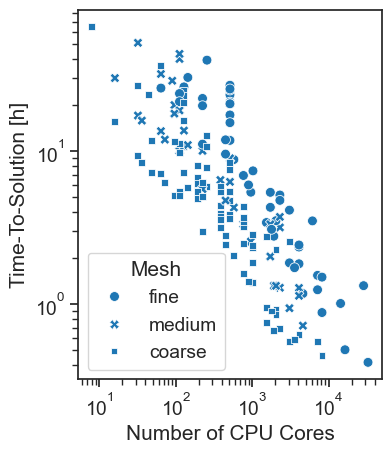

In [12]:
sb.set(style="ticks", font_scale=1.25, palette=sb.color_palette())  # crazy big

ax = sb.scatterplot(df_hardware,x="Number of CPU Cores", y="Time-To-Solution [h]", style="Mesh", s=50)
ax.set(xscale="log", yscale="log") #, title=" Hardware Track")
ax.set(ylabel="Time-To-Solution [h]")
sb.move_legend(ax, "lower left") #, bbox_to_anchor=(1, 1))
fig = ax.get_figure()
plt.gca().set_aspect(2)
op.save_fig(fig, fig_folder, "submissions_overview", doSaveFig)

saving figure to figures_hwtrack/submissions_overview_cpu.png


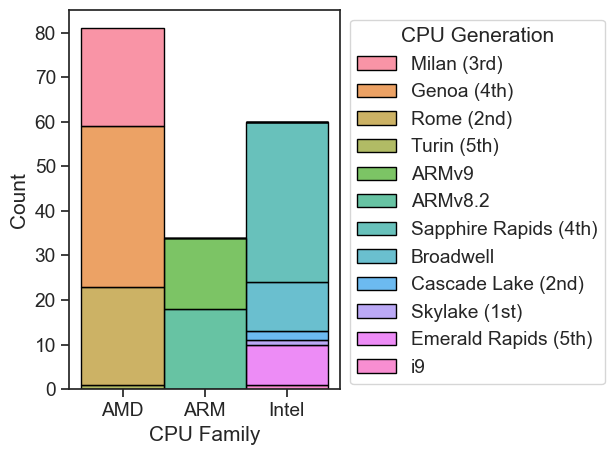

In [278]:
#ax = sb.scatterplot(df_hardware,x="Number of CPU Cores", y="Time-To-Solution [h]", style="Mesh")
#g = sns.FacetGrid(df_hardware, col="time")
#g.map(sns.histplot, "tip")
   
df_hardware["CPU Generation"] = df_hardware["CPU Generation"].apply(lambda x: x.replace("-gen)",")"))
ax = sb.histplot(df_hardware, x="CPU Family",
            hue="CPU Generation",
            #hue="Contributor ID", 
            multiple="stack",
            stat="count",
            ec="k"
           )
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
op.save_fig(ax.get_figure(), fig_folder, "submissions_overview_cpu", doSaveFig)
#sb.countplot(df_hardware, x="Mesh", stat="percent")

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
#sns.set_theme()

counts = df_hardware.apply(pd.Series.value_counts)

# Draw a heatmap with the numeric values in each cell
f, ax = plt.subplots(figsize=(9, 6))
sb.heatmap(flights, annot=True, fmt="d", linewidths=.5, ax=ax)

TypeError: '<' not supported between instances of 'float' and 'str'

In [7]:
len(set(df_hardware["CPU Submodel"]))

20

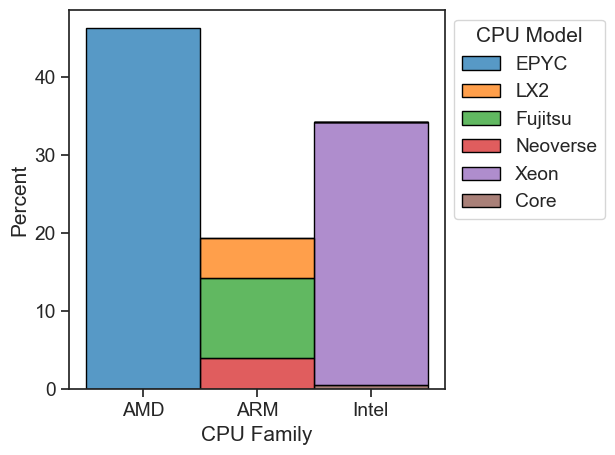

In [279]:
ax = sb.histplot(df_hardware, x="CPU Family",
            hue="CPU Model",
            #hue="Contributor ID", 
            multiple="stack",
            stat="percent",
            ec="k"
           )
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

saving figure to figures_hwtrack/submissions_heatmap.png


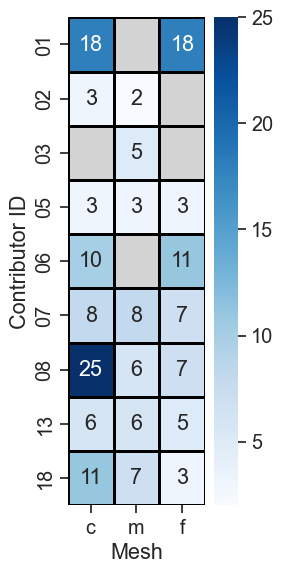

In [312]:
df_filt = df_hardware[["Mesh", "Contributor ID"]]
df_filt_2 = df_filt.groupby(['Contributor ID', "Mesh"], as_index=False).size()
df_filt_2.set_index(["Contributor ID"], inplace=True)
sb.set(style="ticks", font_scale=1.3)  # crazy big

mesh_map = {"coarse":"c", "medium":"m", "fine":"f"}
df_filt_2["Mesh"] = df_filt_2["Mesh"].apply(lambda x: mesh_map[x])
df_filt_2['Mesh'] = pd.Categorical(df_filt_2['Mesh'], ['c','m','f'])
out = df_filt_2.pivot(columns="Mesh")#.fillna(0)#.unstack()

ax = sb.heatmap(out, annot=True, cmap='Blues', linecolor="black", linewidths=0.8, square=False )#sns.cubehelix_palette(as_cmap=True))
ax.set_facecolor('lightgrey')
f= ax.get_figure()
f.set_size_inches(3, 6) 


labels = [item.get_text() for item in ax.get_xticklabels()]
labels = [i.replace("size-", "") for i in labels]
ax.set_xticklabels(labels, rotation=0)

ax.set_xlabel("Mesh")
plt.tight_layout()
op.save_fig(ax.get_figure(), fig_folder, "submissions_heatmap", doSaveFig)

Mesh
coarse    555.071412
fine      682.451769
medium    458.438421
Name: Time-To-Solution [h], dtype: float64


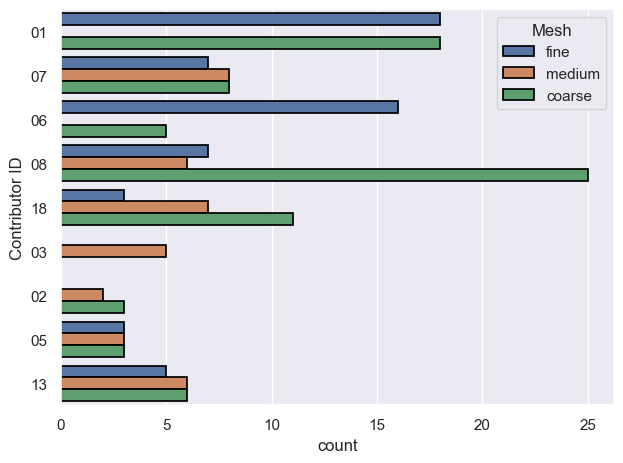

In [161]:
#df_sort = df_hardware.sort_by("Mesh")

time_to_sol = df_hardware.groupby('Mesh')['Time-To-Solution [h]'].sum()
print(time_to_sol)

df_filt = df_hardware

ax = sb.countplot(df_hardware, hue="Mesh",
            #hue="CPU Model",
            y="Contributor ID", 
            #multiple="stack",
            stat="count",
            # order=["coarse", "medium", "fine"],
            edgecolor='black',
            linewidth=1.25,
            #width=0.9,
            #palette=["#bcbddc", "#efedf5"]
            #labels=["555 [h]", "458 [h]", "682 [h]"]
            #palette="rainbow"
           )
#ax.bar_label(ax.containers[0])
#ax.bar_label(ax.containers[0], labels=["555 [h]", "458 [h]", "682 [h]"])

labels = [str(v) if v else '' for v in ax.containers[0].datavalues]

#for p in ax.patches:
#h = p.get_height()
#    labels.append("foo")

#plt.bar_label(ax.containers[0], labels=labels)

#sns.stripplot(planets, x="distance", y="method", size=4, color=".3")


#sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

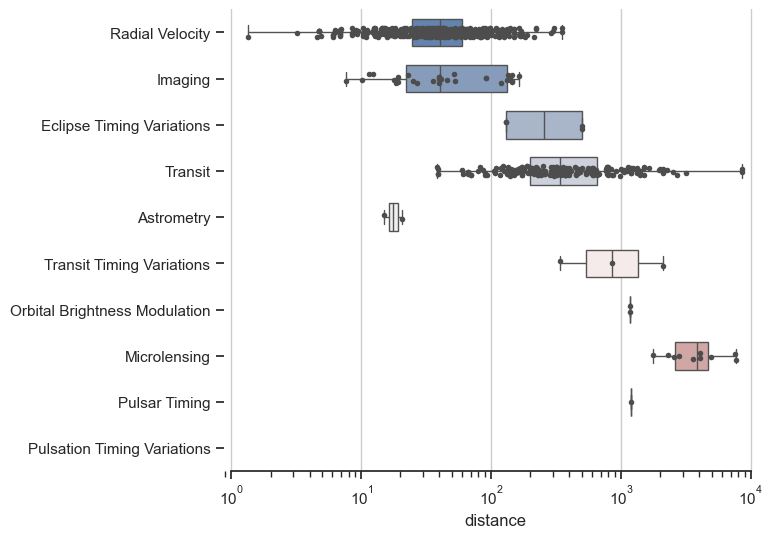

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 6))
ax.set_xscale("log")

# Load the example planets dataset
planets = sns.load_dataset("planets")

# Plot the orbital period with horizontal boxes
sns.boxplot(
    planets, x="distance", y="method", hue="method",
    whis=[0, 100], width=.6, palette="vlag"
)

# Add in points to show each observation
sns.stripplot(planets, x="distance", y="method", size=4, color=".3")

# Tweak the visual presentation
ax.xaxis.grid(True)
ax.set(ylabel="")
sns.despine(trim=True, left=True)

ValueError: <seaborn.axisgrid.FacetGrid object at 0x116e939d0> has no legend attached.

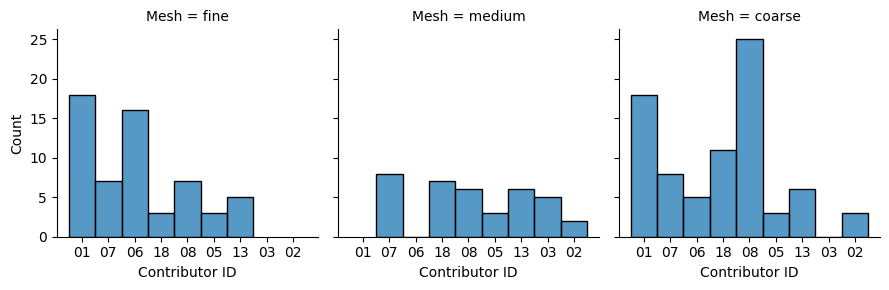

In [58]:
g = sb.FacetGrid(df_hardware, col="Mesh")

ax = g.map(sb.histplot,
            #hue="Number of Nodes",
            x="Contributor ID", 
            multiple="stack",
            stat="count"
           )
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

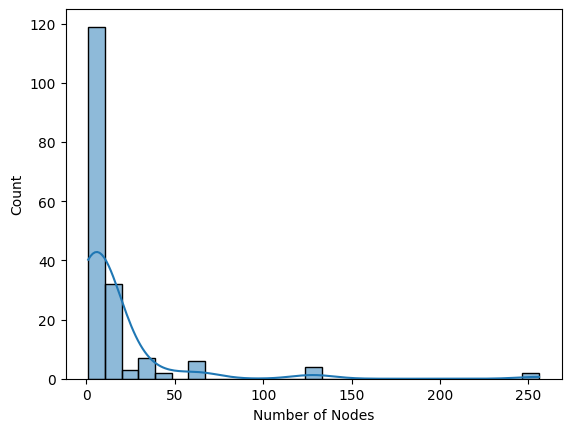

In [44]:
ax = sb.histplot(data=df_hardware, x="Number of Nodes", kde=True)
#ax.set(xscale="log")

[None]

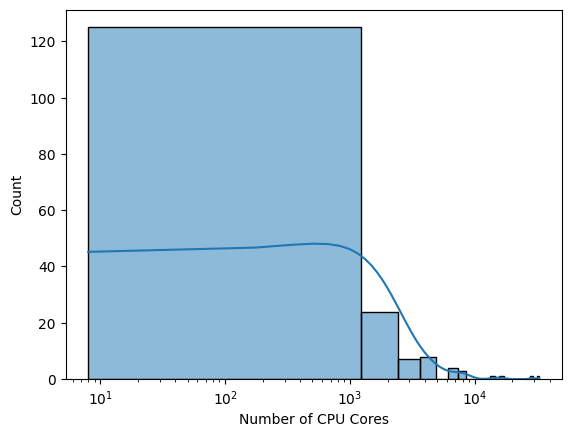

In [45]:
ax = sb.histplot(data=df_hardware, x="Number of CPU Cores", kde=True)
ax.set(xscale="log")
#sb.countplot(df_hardware, x="Mesh", hue="CPU Family", stat="percent")

<Axes: xlabel='Mesh', ylabel='percent'>

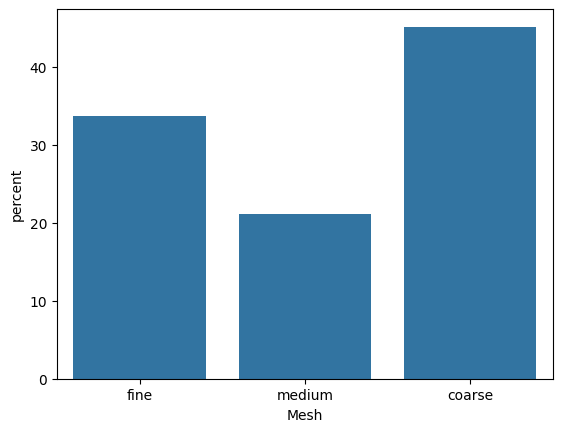

In [11]:
sb.countplot(df_hardware, x="Mesh", stat="percent")

In [7]:
df_hardware.columns

Index(['Contributor Affiliation', 'File Name', 'Run Wall-Clock Time [s]',
       'Pre-Processing Wall-Clock Time [s]', 'Storage File-System',
       'Number of CPU Cores', 'Number of GPU Devices', 'Number of Nodes',
       'CPU Family', 'CPU Model', 'CPU Submodel', 'CPU Generation',
       'GPU Model', 'Mesh', 'System TDP [W]', 'Number of Cells',
       'Time per Iteration [s]', 'Track', 'OpenFOAM Flavor',
       'Run Consumed Energy [kWh]', 'Decomposition Method', 'Last-Level Cache',
       'Network Interconnect', 'Renumbering Method', 'Contributor ID',
       'Is Partial', 'Is Energy Reported', 'Software Optimization Category',
       'Total Core Time [s]', 'Total Node Time [s]',
       'Energy per Iteration [J]', 'Energy per Iteration [kJ]',
       'Energy-To-Solution [kWh]', 'Time-To-Solution [h]',
       'Core-Time-To-Solution [h]', 'Node-Time-To-Solution [h]', 'FVOPS',
       'FVOPS per Energy', 'FVOPS per Energy per Iteration', 'FVOPS per Node'],
      dtype='str')

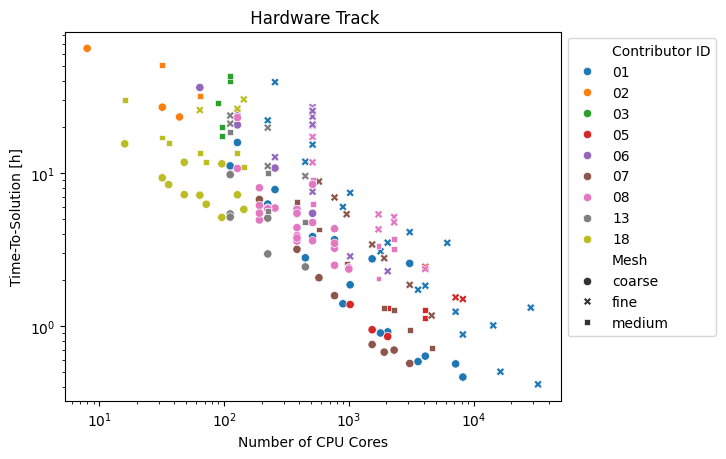

In [213]:
ax = sb.scatterplot(df_hardware.sort_values("Contributor ID"),x="Number of CPU Cores", y="Time-To-Solution [h]", hue="Contributor ID", style="Mesh")
ax.set(xscale="log", yscale="log", title=" Hardware Track")
ax.set(ylabel="Time-To-Solution [h]")
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "wct_cores_mesh", doSaveFig)

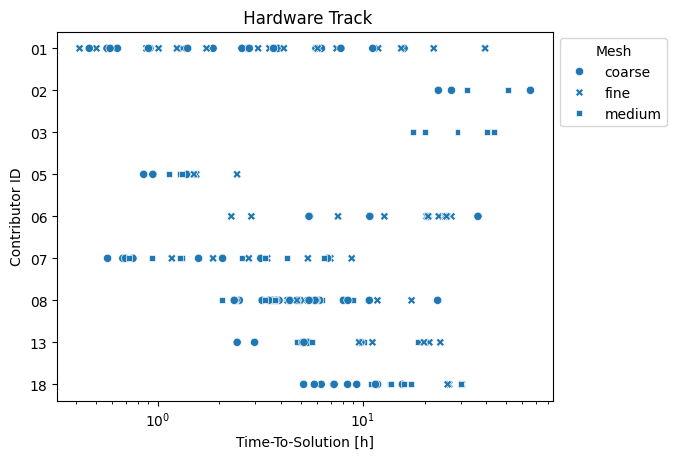

In [214]:

ax = sb.scatterplot(df_hardware.sort_values("Contributor ID"),y="Contributor ID", x="Time-To-Solution [h]", style="Mesh")
ax.set(xscale="log", title=" Hardware Track")
ax.set(xlabel="Time-To-Solution [h]")
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()

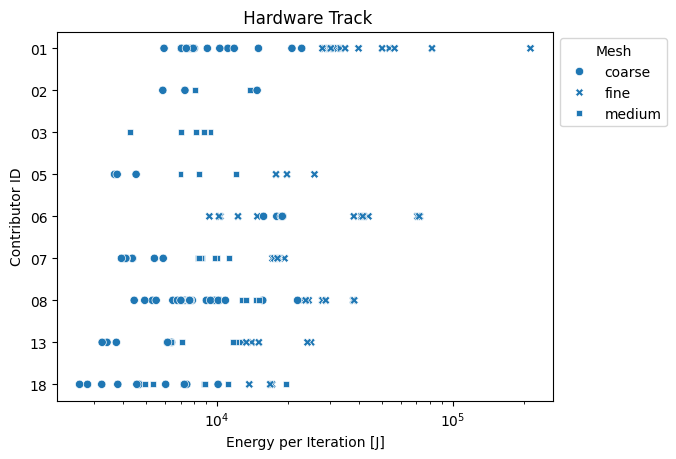

In [215]:

ax = sb.scatterplot(df_hardware.sort_values("Contributor ID"),y="Contributor ID", x="Energy per Iteration [J]", style="Mesh")
ax.set(xscale="log", title=" Hardware Track")
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()

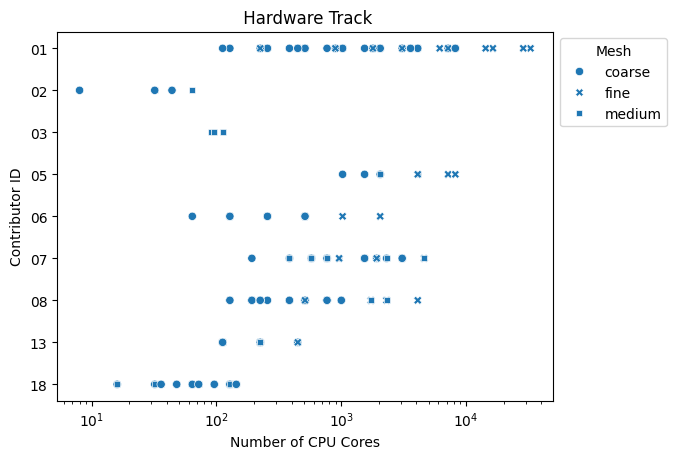

In [216]:

ax = sb.scatterplot(df_hardware.sort_values("Contributor ID"),y="Contributor ID", x="Number of CPU Cores", style="Mesh")
ax.set(xscale="log", title=" Hardware Track")
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "cores_contributor", doSaveFig)

# Performance WCT & Energy

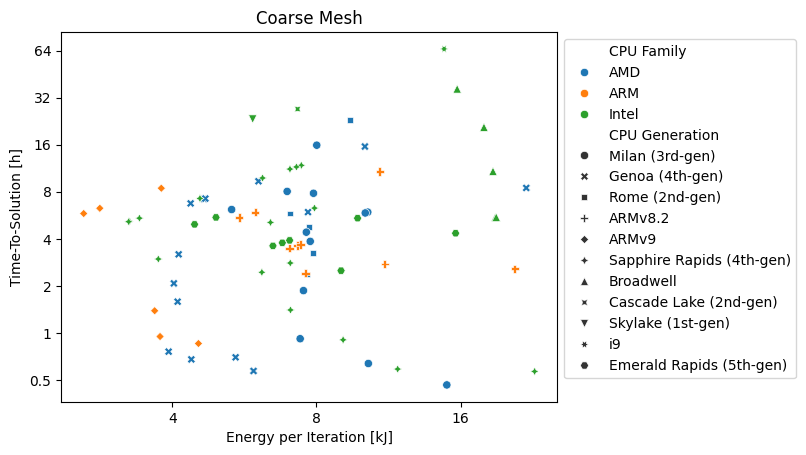

In [217]:
ax = sb.scatterplot(df_hw_coarse.sort_values("CPU Family"),x="Energy per Iteration [kJ]", y="Time-To-Solution [h]", hue="CPU Family", style="CPU Generation")
ax.set(xscale="log", yscale="log", title="Coarse Mesh")
ax.set(ylabel="Time-To-Solution [h]")
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2g'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()

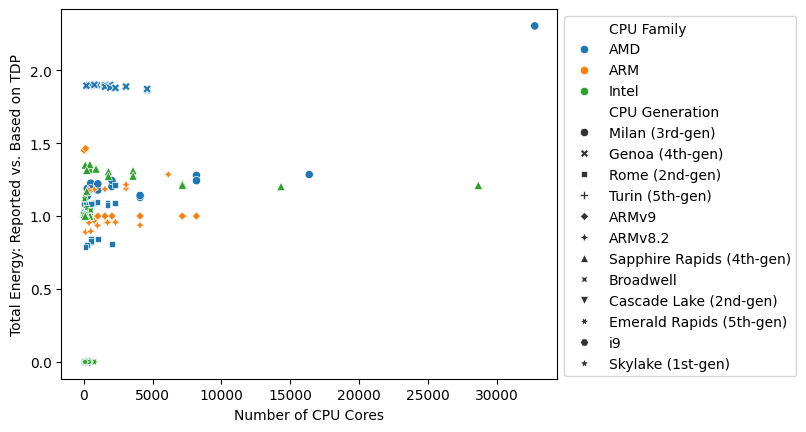

In [218]:
df_hardware["Measured-To-TDP-Energy Ratio"] = df_hardware["Run Consumed Energy [kWh]"] / df_hardware["Energy-To-Solution [kWh]"]
df = df_hardware
ax = sb.scatterplot(df.sort_values("CPU Family"),y="Measured-To-TDP-Energy Ratio", x="Number of CPU Cores", hue="CPU Family", style="CPU Generation")
ax.set(ylabel="Total Energy: Reported vs. Based on TDP")
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "Measured-To-TDP-Energy", doSaveFig)


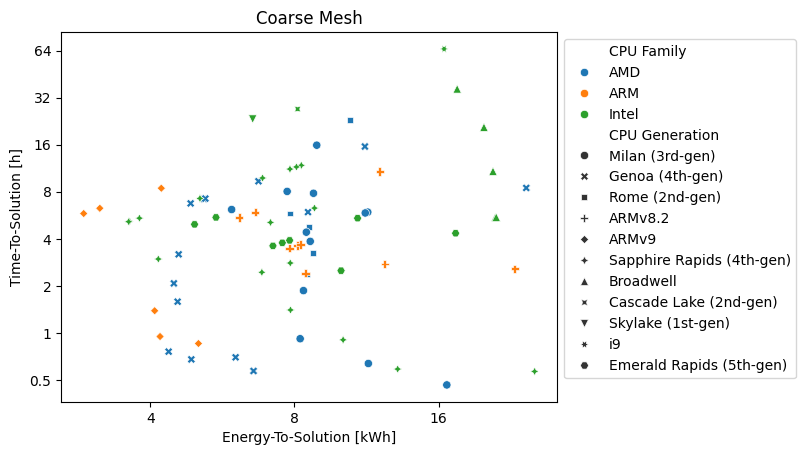

In [219]:

ax = sb.scatterplot(df_hw_coarse.sort_values("CPU Family"),x="Energy-To-Solution [kWh]", y="Time-To-Solution [h]", hue="CPU Family", style="CPU Generation")
ax.set(title="Coarse Mesh")
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2g'))
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "TTS_ETS_coarse", doSaveFig)

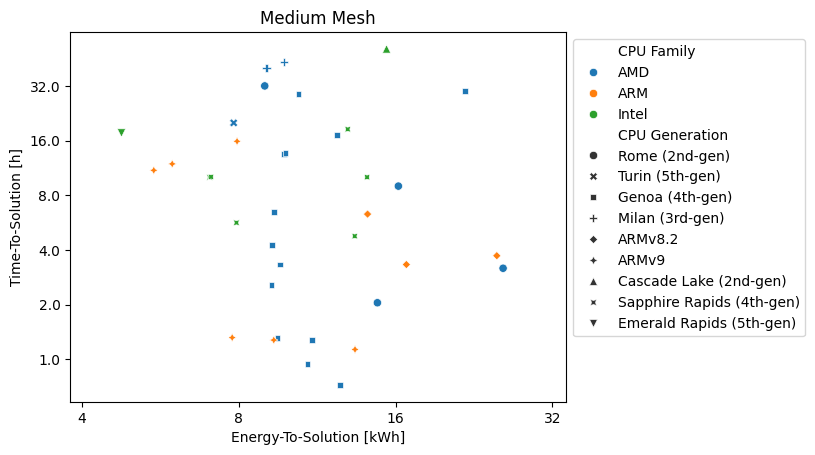

In [220]:

ax = sb.scatterplot(df_hw_medium.sort_values("CPU Family"),x="Energy-To-Solution [kWh]", y="Time-To-Solution [h]", hue="CPU Family", style="CPU Generation")
ax.set(title="Medium Mesh", xlim=[3.8,34])
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.yaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "TTS_ETS_medium", doSaveFig)

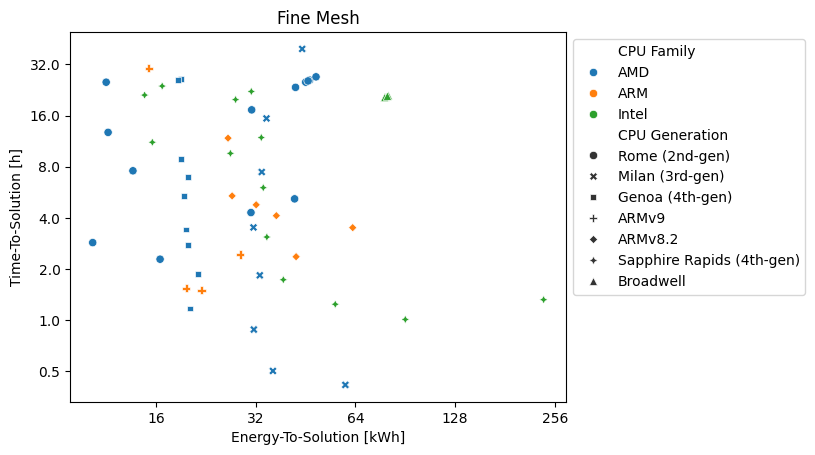

In [221]:

ax = sb.scatterplot(df_hw_fine.sort_values("CPU Family"),x="Energy-To-Solution [kWh]", y="Time-To-Solution [h]", hue="CPU Family", style="CPU Generation")
ax.set(title="Fine Mesh")
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.yaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "TTS_ETS_fine", doSaveFig)

In [132]:
pd.set_option('display.max_rows', 500)

df_hardware[["CPU Generation", "CPU Submodel"]]

,CPU Generation,CPU Submodel
0,Milan (3rd-gen),7763
5,Genoa (4th-gen),9654
4,Genoa (4th-gen),9654
3,Genoa (4th-gen),9654
2,Genoa (4th-gen),9654
1,Genoa (4th-gen),9654
0,Genoa (4th-gen),9654
6,Genoa (4th-gen),9654
5,Genoa (4th-gen),9654
4,Genoa (4th-gen),9654


In [34]:
df_hardware_coarse.columns

Index(['Contributor Affiliation', 'File Name', 'Run Wall-Clock Time [s]',
       'Pre-Processing Wall-Clock Time [s]', 'Storage File-System',
       'Number of CPU Cores', 'Number of GPU Devices', 'Number of Nodes',
       'CPU Family', 'CPU Model', 'CPU Submodel', 'CPU Generation',
       'GPU Model', 'Mesh', 'System TDP [W]', 'Number of Cells',
       'Time per Iteration [s]', 'Track', 'OpenFOAM Flavor',
       'Run Consumed Energy [kWh]', 'Decomposition Method', 'Last-Level Cache',
       'Network Interconnect', 'Renumbering Method', 'Contributor ID',
       'Is Partial', 'Is Energy Reported', 'Software Optimization Category',
       'Total Core Time [s]', 'Total Node Time [s]',
       'Energy per Iteration [J]', 'Energy per Iteration [kJ]',
       'Energy-To-Solution [kWh]', 'Time-To-Solution [h]',
       'Core-Time-To-Solution [h]', 'Node-Time-To-Solution [h]', 'FVOPS',
       'FVOPS per Energy', 'FVOPS per Energy per Iteration', 'FVOPS per Node'],
      dtype='str')

26 2020
44 2022
83 2024
8 2020
16 2022
36 2024
20 2020
32 2022
54 2024
saving figure to figures_hwtrack/TTS_ETS_facetGrid_pareto_year.png


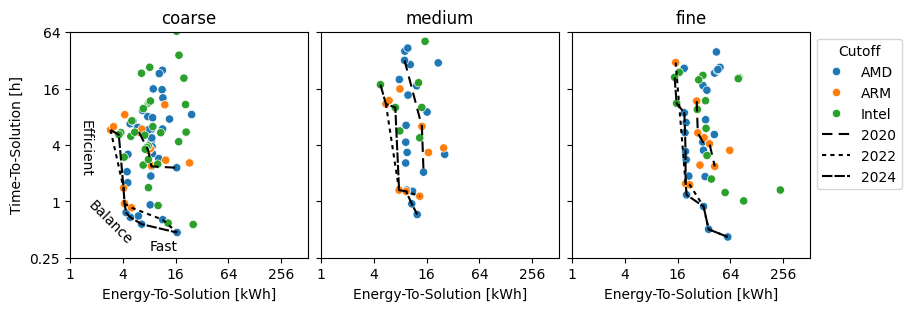

In [135]:
from paretoset import paretoset


fig, axs = plt.subplots(1, 3, figsize=(9, 3), layout="constrained", gridspec_kw={"hspace": 0.1}, sharey=True, sharex=True)

release_map_orig = {
    "i9": 2024, # Feb. 2024
    'Milan (3rd-gen)': 2021, 
    "Genoa (4th-gen)": 2022, 
    'Rome (2nd-gen)': 2019, 
    'Sapphire Rapids (4th-gen)': 2023,
    "Cascade Lake (2nd-gen)": 2019,
    "Turin (5th-gen)": 2024,
    "Broadwell" : 2014,
    "Skylake (1st-gen)": 2015,
    "Emerald Rapids (5th-gen)": 2023,
    'ARMv8.2': 2016,
    'ARMv9': 2021}

release_map = {
    "i9": "2020-2024",
    'Milan (3rd-gen)': "2020-2024", 
    "Genoa (4th-gen)": "2020-2024", 
    'Rome (2nd-gen)': "2014-2020", 
    'Sapphire Rapids (4th-gen)': "2020-2024",
    "Cascade Lake (2nd-gen)": "2014-2020",
    "Turin (5th-gen)": "2020-2024",
    "Broadwell" : "2014-2020",
    "Skylake (1st-gen)": "2014-2020",
    "Emerald Rapids (5th-gen)": "2020-2024",
    'ARMv8.2': "2014-2020",
    'ARMv9': "2020-2024"}

release_map_2 = { # <2018 2018-2022, 2023+
    "i9": ">=2022",
    'Milan (3rd-gen)': "2018-2021", 
    "Genoa (4th-gen)": ">=2022",  
    'Rome (2nd-gen)': "2018-2021", 
    'Sapphire Rapids (4th-gen)': ">=2022",
    "Cascade Lake (2nd-gen)": "2018-2021", 
    "Turin (5th-gen)": ">=2022",
    "Broadwell" : "<2018",
    "Skylake (1st-gen)": "<2018",
    "Emerald Rapids (5th-gen)": ">=2022",
    'ARMv8.2': "<2018",
    'ARMv9': "2018-2021"}

df_hardware["year"] = 0
df_hardware["year"] = df_hardware["CPU Generation"].apply(lambda x: release_map_orig[x])
df_hardware["Year (binned)"] = df_hardware["CPU Generation"].apply(lambda x: release_map_2[x])


for i, mesh in enumerate(["coarse", "medium", "fine"]):
    df_hardware_coarse = df_hardware[df_hardware["Mesh"] == mesh]
    ax = sb.scatterplot(df_hardware_coarse,x="Energy-To-Solution [kWh]", y="Time-To-Solution [h]", hue="CPU Family", ax=axs[i])
    ax.set_title(mesh)

    for year in  [2020, 2022, 2024]: #["2014-2020", "2020-2024"]: # ["2014-2020", "2020-2022", "2022-2024"]:
        dash_map={
            2017: [(1, 5)],
            2020: [(5, 3)],
            2022: [(2, 2)],
            2024: [(5, 1)],
        }
    
        df_year = df_hardware_coarse[df_hardware_coarse["year"] < year]
        print(len(df_year), year)
        df_year["Cutoff"] = year
        mask = paretoset(df_year[["Time-To-Solution [h]", "Energy-To-Solution [kWh]"]], sense=[min, min])
        axII=sb.lineplot(
            df_year[mask], x="Energy-To-Solution [kWh]", 
            y="Time-To-Solution [h]", ax=axs[i], color="black", 
            style="Cutoff", dashes=dash_map[year]
        )
    if i != 2:
        ax.get_legend().set_visible(False)

for ax in axs.flat:
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.4g'))
    ax.set_yscale("log", base=2)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.4g'))
    ax.set_xlim([1, 512])
    ax.set_ylim([0.25, 65])

axs[0].text(8, 0.3, "Fast") #, ha="left", va="top", transform=ax.transAxes)
axs[0].text(1.25, 2.0, "Efficient", rotation=-90) #, ha="left", va="top", transform=ax.transAxes)
axs[0].text(1.5, 0.35, "Balance", rotation=-45) #, ha="left", va="top", transform=ax.transAxes)

fig = ax.get_figure()
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
op.save_fig(fig, fig_folder, "TTS_ETS_facetGrid_pareto_year", doSaveFig)

In [143]:
help(paretoset)

Help on function paretoset in module paretoset.user_interface:

paretoset(costs, sense=None, distinct=True, use_numba=True)
    Return boolean mask indicating the Pareto set of (non-NaN) numerical data.

    The input data in `costs` can be either a pandas DataFrame or a NumPy ndarray
    of shape (observations, objectives). The user is responsible for dealing with
    NaN values *before* sending data to this function. Only numerical data is
    allowed, with the exception of `diff` (different) columns.

    Parameters
    ----------
    costs : np.ndarray or pd.DataFrame
        Array or DataFrame of shape (observations, objectives).
    sense : list
        List with strings for each column (objective). The value `min` (default)
        indicates minimization, `max` indicates maximization and `diff` indicates
        different values. Using `diff` is equivalent to a group-by operation
        over the columns marked with `diff`. If None, minimization is assumed.
    distinct : bool
 

saving figure to figures_hwtrack/TTS_ETS_facetGrid.png


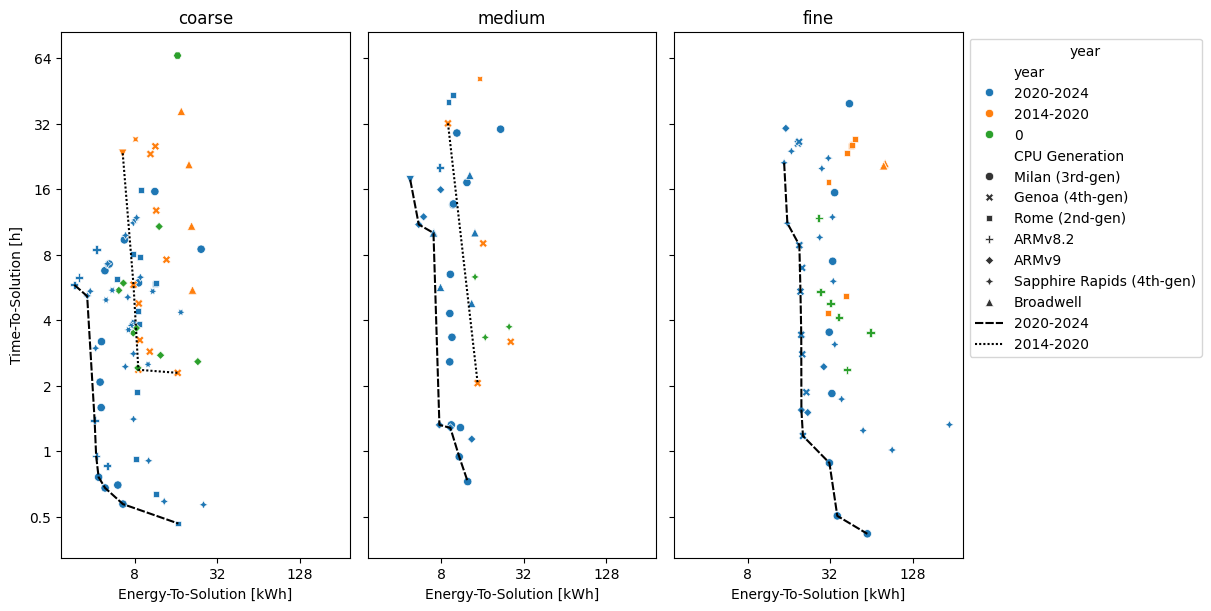

In [69]:
from paretoset import paretoset

fig, axs = plt.subplots(1, 3, figsize=(12, 6), layout="constrained", gridspec_kw={"hspace": 0.1}, sharey=True, sharex=True)

release_map_orig = {
    "i9": 0,
    'Milan (3rd-gen)': 2021, 
    "Genoa (4th-gen)": 2022, 
    'Rome (2nd-gen)': 2019, 
    'Sapphire Rapids (4th-gen)': 2023,
    "Cascade Lake (2nd-gen)": 2019,
    "Turin (5th-gen)": 2024,
    "Broadwell" : 2014,
    "Skylake (1st-gen)": 2015,
    "Emerald Rapids (5th-gen)": 2023,
    'ARMv8.2': 2016,
    'ARMv9': 2021}

release_map = {
    "i9": 0,
    'Milan (3rd-gen)': "2020-2024", 
    "Genoa (4th-gen)": "2020-2024", 
    'Rome (2nd-gen)':  "2014-2020", 
    'Sapphire Rapids (4th-gen)': "2020-2024",
    "Cascade Lake (2nd-gen)": "2014-2020",
    "Turin (5th-gen)": "2020-2024",
    "Broadwell" : "2014-2020",
    "Skylake (1st-gen)": "2014-2020",
    "Emerald Rapids (5th-gen)": "2020-2024",
    'ARMv8.2': 0, #"2014-2020",
    'ARMv9': "2020-2024"}

df_hardware["year"] = 0
df_hardware["year"] = df_hardware["CPU Generation"].apply(lambda x: release_map[x])


for i, mesh in enumerate(["coarse", "medium", "fine"]):
    df_hardware_coarse = df_hardware[df_hardware["Mesh"] == mesh]
    ax = sb.scatterplot(df_hardware_coarse,x="Energy-To-Solution [kWh]", y="Time-To-Solution [h]", hue="year", style="CPU Generation", ax=axs[i])
    ax.set_title(mesh)

    for year in set(df_hardware["year"]):
        dashes=[(4, 1)]
        if year == 0:
            continue
        if year == "2014-2020":
            dashes=[(1, 1)]
        df_year = df_hardware_coarse[df_hardware_coarse["year"] == year]
        mask = paretoset(df_year[["Time-To-Solution [h]", "Energy-To-Solution [kWh]"]], sense=[min, min])
        axII=sb.lineplot(
            df_year[mask], x="Energy-To-Solution [kWh]", 
            y="Time-To-Solution [h]", ax=axs[i], color="black", 
            style="year", dashes=dashes
        )
    
    if i != 2:
        ax.get_legend().set_visible(False)

for ax in axs.flat:
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.4g'))
    ax.set_yscale("log", base=2)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.4g'))

fig = ax.get_figure()
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
op.save_fig(fig, fig_folder, "TTS_ETS_facetGrid", doSaveFig)

In [76]:
df_hardware.columns

Index(['Contributor Affiliation', 'File Name', 'Run Wall-Clock Time [s]',
       'Pre-Processing Wall-Clock Time [s]', 'Storage File-System',
       'Number of CPU Cores', 'Number of GPU Devices', 'Number of Nodes',
       'CPU Family', 'CPU Model', 'CPU Submodel', 'CPU Generation',
       'GPU Model', 'Mesh', 'System TDP [W]', 'Number of Cells',
       'Time per Iteration [s]', 'Track', 'OpenFOAM Flavor',
       'Run Consumed Energy [kWh]', 'Decomposition Method', 'Last-Level Cache',
       'Network Interconnect', 'Renumbering Method', 'Contributor ID',
       'Is Partial', 'Is Energy Reported', 'Software Optimization Category',
       'Total Core Time [s]', 'Total Node Time [s]',
       'Energy per Iteration [J]', 'Energy per Iteration [kJ]',
       'Energy-To-Solution [kWh]', 'Time-To-Solution [h]',
       'Core-Time-To-Solution [h]', 'Node-Time-To-Solution [h]', 'FVOPS',
       'FVOPS per Energy', 'FVOPS per Energy per Iteration', 'FVOPS per Node',
       'year'],
      dtype='str'

In [95]:
pd.cut(df_hardware["Number of Nodes"], bins=[0.1,1,2,16,1024], labels=["a","b","c", "d"])

0    b
5    c
4    c
3    c
2    c
    ..
0    a
1    b
3    a
5    a
5    c
Name: Number of Nodes, Length: 175, dtype: category
Categories (4, str): ['a' < 'b' < 'c' < 'd']

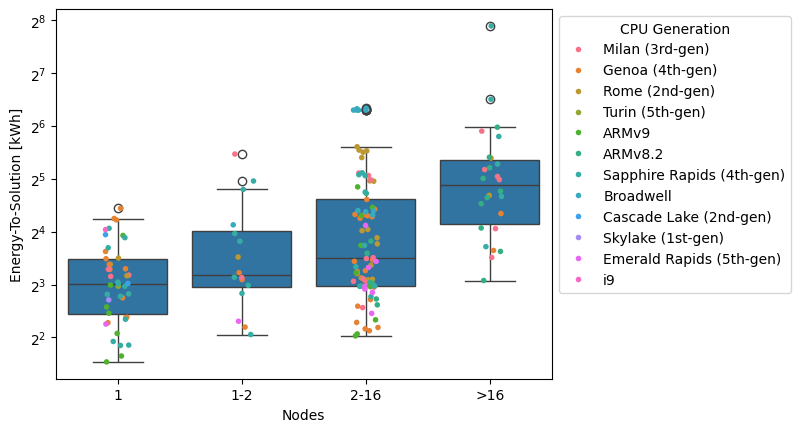

In [106]:
df_hardware["Nodes"] = pd.cut(df_hardware["Number of Nodes"], bins=[0.1,1,2,16,64000], labels=["1","1-2","2-16", ">16"])
ax = sb.boxplot(df_hardware, y="Energy-To-Solution [kWh]", x="Nodes") #, native_scale=True)
# Add in points to show each observation
sb.stripplot(df_hardware, x="Nodes", y="Energy-To-Solution [kWh]", size=4, hue="CPU Generation")
ax.set_yscale("log", base=2)
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


In [203]:
df_hardware.columns

Index(['Contributor Affiliation', 'File Name', 'Run Wall-Clock Time [s]',
       'Pre-Processing Wall-Clock Time [s]', 'Storage File-System',
       'Number of CPU Cores', 'Number of GPU Devices', 'Number of Nodes',
       'CPU Family', 'CPU Model', 'CPU Submodel', 'CPU Generation',
       'GPU Model', 'Mesh', 'System TDP [W]', 'Number of Cells',
       'Time per Iteration [s]', 'Track', 'OpenFOAM Flavor',
       'Run Consumed Energy [kWh]', 'Decomposition Method', 'Last-Level Cache',
       'Network Interconnect', 'Renumbering Method', 'Contributor ID',
       'Is Partial', 'Is Energy Reported', 'Software Optimization Category',
       'Total Core Time [s]', 'Total Node Time [s]',
       'Energy per Iteration [J]', 'Energy per Iteration [kJ]',
       'Energy-To-Solution [kWh]', 'Time-To-Solution [h]',
       'Core-Time-To-Solution [h]', 'Node-Time-To-Solution [h]', 'FVOPS',
       'FVOPS per Energy', 'FVOPS per Energy per Iteration', 'FVOPS per Node',
       'year', 'Nodes'],
      dt

In [212]:
set(df_hardware["Number of Nodes"])

{1, 2, 3, 4, 5, 6, 8, 10, 12, 14, 16, 18, 24, 25, 32, 36, 48, 64, 128, 256}

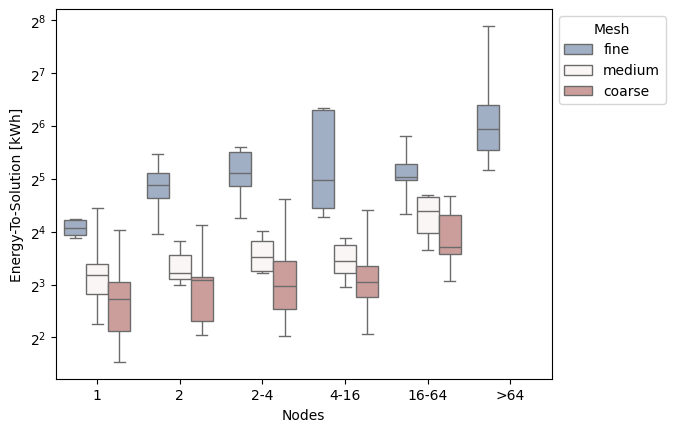

In [148]:
df_hardware["Nodes"] = pd.cut(df_hardware["Number of Nodes"], bins=[0.1,1,2,4,16, 64,64000], labels=["1","2","2-4","4-16", "16-64", ">64"])
df_hardware["Cells per Core"] = df_hardware["Number of Cells"]/df_hardware["Number of CPU Cores"]

ax = sb.boxplot(df_hardware, y="Energy-To-Solution [kWh]", x="Nodes", hue="Mesh", palette="vlag", whis=(0, 100)) #, native_scale=True)
    # Add in points to show each observation
#sb.stripplot(df_hardware, x="Nodes", y="Energy-To-Solution [kWh]", size=4, hue="Mesh", linewidth=0.5)
ax.set_yscale("log", base=2)
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

In [151]:
df_hardware.columns

Index(['Contributor Affiliation', 'File Name', 'Run Wall-Clock Time [s]',
       'Pre-Processing Wall-Clock Time [s]', 'Storage File-System',
       'Number of CPU Cores', 'Number of GPU Devices', 'Number of Nodes',
       'CPU Family', 'CPU Model', 'CPU Submodel', 'CPU Generation',
       'GPU Model', 'Mesh', 'System TDP [W]', 'Number of Cells',
       'Time per Iteration [s]', 'Track', 'OpenFOAM Flavor',
       'Run Consumed Energy [kWh]', 'Decomposition Method', 'Last-Level Cache',
       'Network Interconnect', 'Renumbering Method', 'Contributor ID',
       'Is Partial', 'Is Energy Reported', 'Software Optimization Category',
       'Total Core Time [s]', 'Total Node Time [s]',
       'Energy per Iteration [J]', 'Energy per Iteration [kJ]',
       'Energy-To-Solution [kWh]', 'Time-To-Solution [h]',
       'Core-Time-To-Solution [h]', 'Node-Time-To-Solution [h]', 'FVOPS',
       'FVOPS per Energy', 'FVOPS per Energy per Iteration', 'FVOPS per Node',
       'Nodes', 'Cells per Core',

KeyError: 'year'

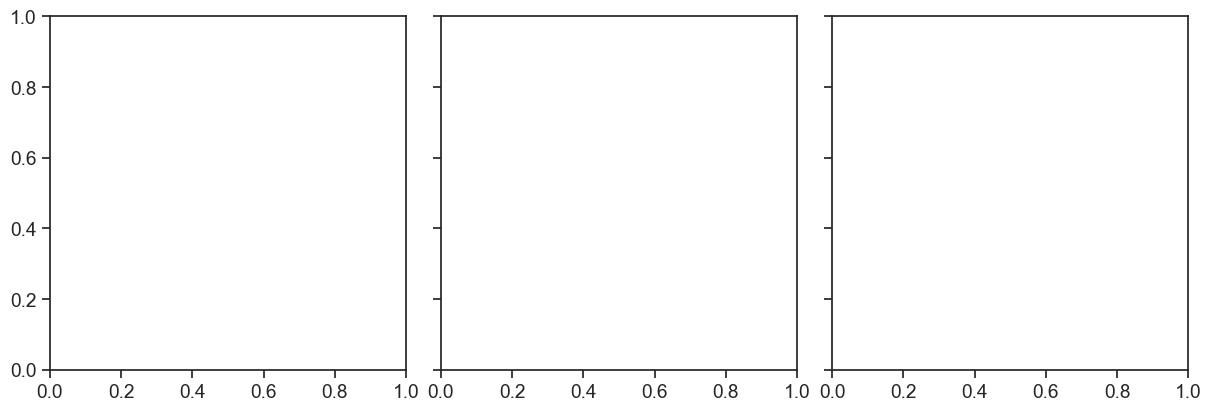

In [21]:

fig, axs = plt.subplots(1, 3, figsize=(12, 4), layout="constrained", gridspec_kw={"hspace": 0.1}, sharey=True, sharex=True)

df_hardware["Nodes [#]"] = pd.cut(df_hardware["Number of Nodes"], bins=[0.1,1,2,4,16, 64,64000], labels=["1","2","4","16", "64", ">64"])

coresbin = [1,32,64,128,256,512,1024,2048, 4096, 8192, 16384, 32768]
df_hardware["Cores [#]"] = pd.cut(df_hardware["Number of CPU Cores"], 
                              bins=coresbin,
                              labels=["<"+str(_) for _ in coresbin[1:]])


df_hardware["Year"] = df_hardware["year"].apply(lambda x: str(x))


#cmap = sb.color_palette("deep", len(set(df_hardware["year"])))

for i,m in enumerate(["fine", "medium", "coarse"]):
    df_filt = df_hardware[df_hardware["Mesh"] == m]
    sb.scatterplot(
        df_filt, x="Cores [#]", y="Time-To-Solution [h]",# color="black",
        #linewidth=0.1,
        size_norm=5, hue="CPU Family", style="CPU Generation", ax=axs[i], zorder=20, s=50, )
    #df_filt["Cells per Core"] = df_hardware["Number of Cells"]/df_hardware["Number of CPU Cores"]
    ax = sb.boxplot(df_filt, y="Time-To-Solution [h]", x="Cores [#]", 
               #hue="CPU Family",
               #palette="vlag", 
               #color="white",
               whis=(0, 100),
               ax = axs[i],#, title=m
               #, native_scale=True
            )
    for patch in ax.patches:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, .01))
    

    ax.set_title(m)
    if i != 2:
        axs[i].get_legend().set_visible(False)

# Add in points to show each observation
#sb.stripplot(df_hardware, x="Nodes", y="Energy-To-Solution [kWh]", size=4, hue="Mesh", linewidth=0.5)



for i, ax in enumerate(axs.flat):
    def one_over(x):
        """Vectorized 1/x, treating x==0 manually"""
        print(x)
        x = np.array(x, float)
        return x/63e6


    # the function "1/x" is its own inverse
    inverse = one_over
    
    #ax.set_xscale("log", base=2)
    #ax.xaxis.set_major_formatter(FormatStrFormatter('%.4g'))
    ax.set_yscale("log", base=2)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.4g'))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    #secax = ax.secondary_xaxis('top', functions=(one_over, inverse))
    #secax.set_xlabel('Cells per Core [#]')




ax.set_yscale("log", base=2)
sb.move_legend(axs[2], "upper left", bbox_to_anchor=(1.05, 1.05))
op.save_fig(fig, fig_folder, "TTS_Cores_facetGrid_alt", doSaveFig)

/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_63329/2770148827.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


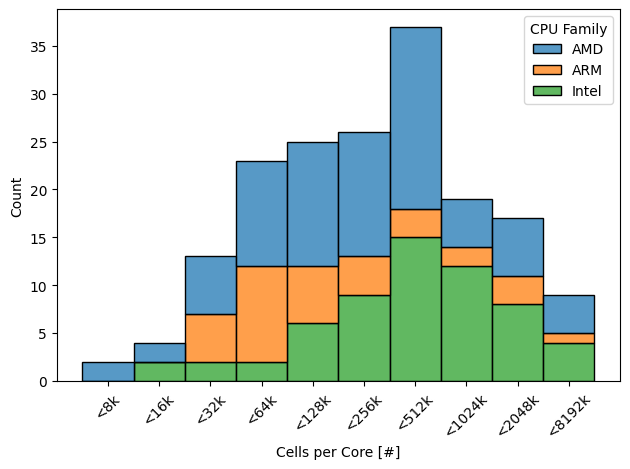

In [198]:
#g = sb.FacetGrid(df_hardware, col="CPU Family")
df_hardware["Cells per Core"] = df_hardware["Number of Cells"]/ df_hardware["Number of CPU Cores"]
cellsbin = [1, 8000, 16000, 32000, 64000, 128000, 256000, 512000, 512000*2, 512000*4, 512000*16]
df_hardware["Cells per Core [#]"] = pd.cut(df_hardware["Cells per Core"], 
                              bins=cellsbin,
                              labels=["<"+str(int((_/1000)))+"k" for _ in cellsbin[1:]]
                            )



#sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

#for i, ax in enumerate(axs.axes.flat):

    # the function "1/x" is its own inverse
    #inverse = one_over
    
    #ax.set_xscale("log", base=2)
    #ax.xaxis.set_major_formatter(FormatStrFormatter('%.4g'))
    #ax.set_yscale("log", base=2)
    #ax.yaxis.set_major_formatter(FormatStrFormatter('%.4g'))
    #secax = ax.secondary_xaxis('top', functions=(one_over, inverse))
    #secax.set_xlabel('Cells per Core [#]')
plt.tight_layout()
    

In [233]:
df_hardware.columns

Index(['Contributor Affiliation', 'File Name', 'Run Wall-Clock Time [s]',
       'Pre-Processing Wall-Clock Time [s]', 'Storage File-System',
       'Number of CPU Cores', 'Number of GPU Devices', 'Number of Nodes',
       'CPU Family', 'CPU Model', 'CPU Submodel', 'CPU Generation',
       'GPU Model', 'Mesh', 'System TDP [W]', 'Number of Cells',
       'Time per Iteration [s]', 'Track', 'OpenFOAM Flavor',
       'Run Consumed Energy [kWh]', 'Decomposition Method', 'Last-Level Cache',
       'Network Interconnect', 'Renumbering Method', 'Contributor ID',
       'Is Partial', 'Is Energy Reported', 'Software Optimization Category',
       'Total Core Time [s]', 'Total Node Time [s]',
       'Energy per Iteration [J]', 'Energy per Iteration [kJ]',
       'Energy-To-Solution [kWh]', 'Time-To-Solution [h]',
       'Core-Time-To-Solution [h]', 'Node-Time-To-Solution [h]', 'FVOPS',
       'FVOPS per Energy', 'FVOPS per Energy per Iteration', 'FVOPS per Node',
       'Nodes', 'Cells per Core',

/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_80328/2947988320.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_80328/2947988320.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_80328/2947988320.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_80328/2947988320.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fi

saving figure to figures_hwtrack/scaling_count_cpu.png


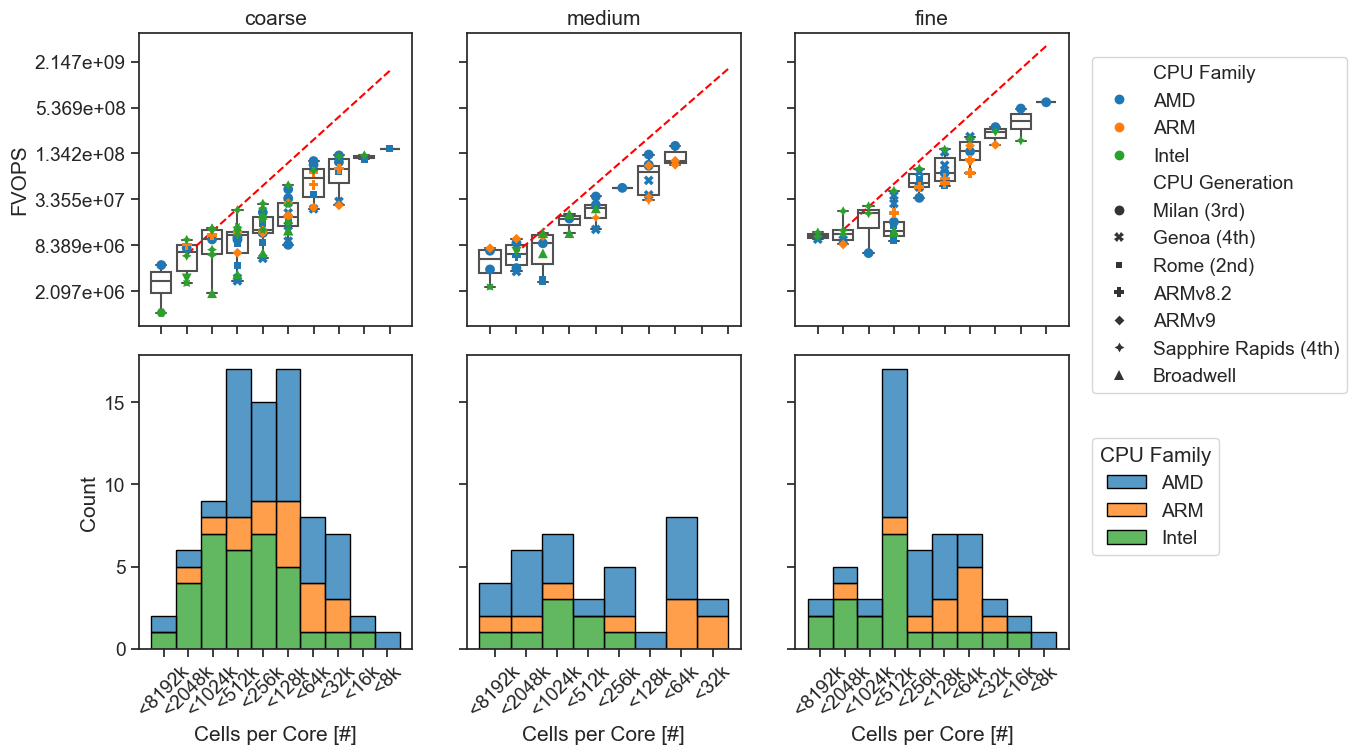

In [26]:
sb.set(style="ticks", font_scale=1.25, palette=sb.color_palette())  # crazy big

fig, axs = plt.subplots(2, 3, figsize=(12, 8), layout="constrained", gridspec_kw={"hspace": 0.1}, sharey="row") # , sharex="col")
df_hardware["FVOPS per Core"] = df_hardware["FVOPS"] / df_hardware["Number of CPU Cores"]
df_hardware["CPU Generation"] = df_hardware["CPU Generation"].apply(lambda x: x.replace("-gen)",")"))

df_hardware["Cells per Core"] = df_hardware["Number of Cells"]/ df_hardware["Number of CPU Cores"]
cellsbin = [1, 8000, 16000, 32000, 64000, 128000, 256000, 512000, 512000*2, 512000*4, 512000*16]
df_hardware["Cells per Core [#]"] = pd.cut(df_hardware["Cells per Core"], 
                              bins=cellsbin,
                              labels=["<"+str(int((_/1000)))+"k" for _ in cellsbin[1:]]
                            )

for i,m in enumerate(["coarse", "medium", "fine"]):
    df_filt = df_hardware[df_hardware["Mesh"] == m]
    # get average for mesh and Cells per Core [#] == <8192k
    mean = df_filt[df_filt['Cells per Core [#]'] == "<2048k"]["FVOPS"].mean()
    
    sb.scatterplot(
        df_filt, x="Cells per Core [#]", y="FVOPS",# color="black",
        #linewidth=0.1,
        size_norm=5, hue="CPU Family", style="CPU Generation", ax=axs[0][i], zorder=20, s=50,   linewidth=0,)
    ax = sb.boxplot(df_filt, 
               y="FVOPS",
               x="Cells per Core [#]", 
               #hue="CPU Family",
               #palette="vlag", 
               #color="white",
               whis=(0, 100),
               ax = axs[0][i],
               linewidth=1.5
               #lw=1.2#, title=m
               #, native_scale=True
            )

    data = pd.DataFrame.from_dict({"FVOPS":[mean, mean*2048/8],
         "Cells per Core [#]": ["<2048k", "<8k"]}
    )

    sb.lineplot(data, x= "Cells per Core [#]",  y="FVOPS", ax=axs[0][i], color='red', linestyle="--")
    
    for patch in ax.patches:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, .01))
    
    ax.set_title(m)
    if i != 2:
        axs[0][i].get_legend().set_visible(False)
    
    df_filt = df_hardware[df_hardware["Mesh"] == m]
    ax = sb.histplot(
           data=df_filt,
            hue="CPU Family",
            x="Cells per Core [#]", 
            multiple="stack",
            stat="count", 
            ax=axs[1][i],
            ec="k"
        )
    if i != 2:
        axs[1][i].get_legend().set_visible(False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

for i, ax in enumerate(axs[0]):
    ax.set_yscale("log", base=2)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.4g'))
    ax.set_xticklabels(ax.get_xticklabels(), visible=None)
    ax.set_xlabel("")
    ax.invert_xaxis()
for i, ax in enumerate(axs[1]):
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.invert_xaxis()

    
sb.move_legend(axs[0][2], "upper left", bbox_to_anchor=(1.05, 0.95))
sb.move_legend(axs[1][2], "upper left", bbox_to_anchor=(1.05, 0.75))

plt.tight_layout()
op.save_fig(fig, fig_folder, "scaling_count_cpu", doSaveFig)

/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_80328/460253272.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


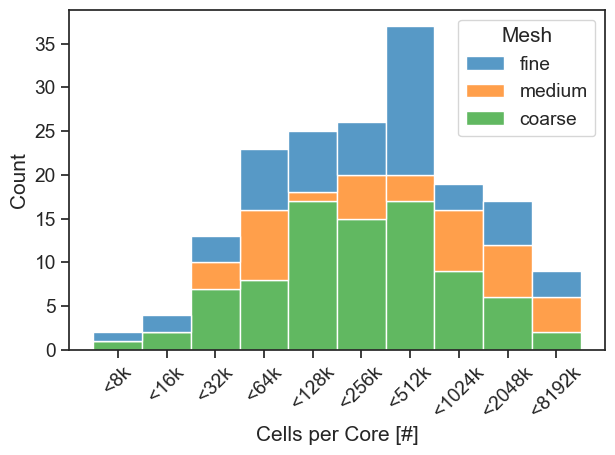

In [24]:
ax = sb.histplot(
           data=df_hardware,
            hue="Mesh",
            x="Cells per Core [#]", 
            multiple="stack",
            stat="count"
           )
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

#sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

#for i, ax in enumerate(axs.axes.flat):

    # the function "1/x" is its own inverse
    #inverse = one_over
    
    #ax.set_xscale("log", base=2)
    #ax.xaxis.set_major_formatter(FormatStrFormatter('%.4g'))
    #ax.set_yscale("log", base=2)
    #ax.yaxis.set_major_formatter(FormatStrFormatter('%.4g'))
    #secax = ax.secondary_xaxis('top', functions=(one_over, inverse))
    #secax.set_xlabel('Cells per Core [#]')
plt.tight_layout()

/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_63329/601529467.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_63329/601529467.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_63329/601529467.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


saving figure to figures_hwtrack/TTS_Cores_facetGrid_alt.png


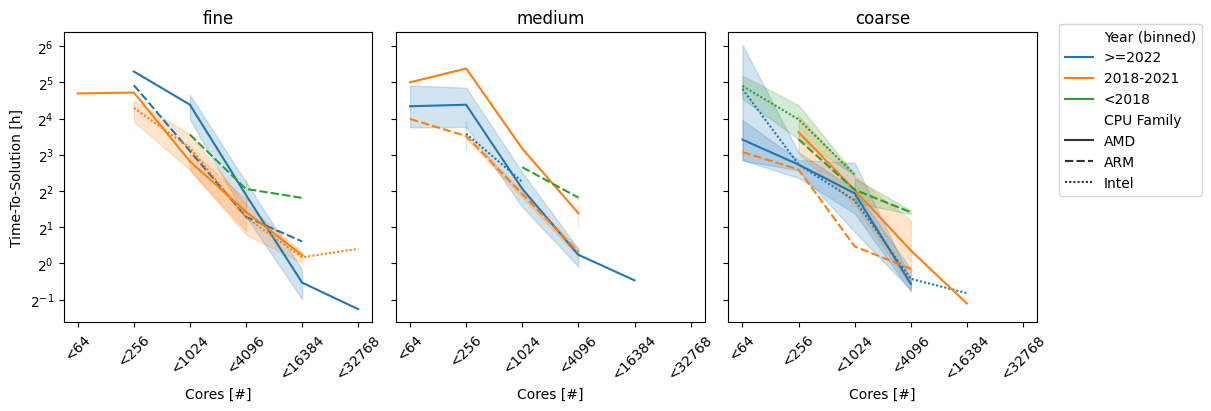

In [138]:

fig, axs = plt.subplots(1, 3, figsize=(12, 4), layout="constrained", gridspec_kw={"hspace": 0.1}, sharey=True, sharex=True)

df_hardware["Nodes [#]"] = pd.cut(df_hardware["Number of Nodes"], bins=[0.1,1,2,4,16, 64,64000], labels=["1","2","4","16", "64", ">64"])

coresbin = [1,64,256,1024, 4096, 16384, 32768]
df_hardware["Cores [#]"] = pd.cut(df_hardware["Number of CPU Cores"], 
                              bins=coresbin,
                              labels=["<"+str(_) for _ in coresbin[1:]])

#df_hardware["Year"] = df_hardware["year"].apply(lambda x: str(x))


#cmap = sb.color_palette("deep", len(set(df_hardware["year"])))

for i,m in enumerate(["fine", "medium", "coarse"]):
    df_filt = df_hardware[df_hardware["Mesh"] == m]
    #sb.scatterplot(
    #    df_filt, x="Cores [#]", y="Time-To-Solution [h]",# color="black",
    #    #linewidth=0.1,
    #    size_norm=5, hue="CPU Family", style="CPU Generation", ax=axs[i], zorder=20)
    #df_filt["Cells per Core"] = df_hardware["Number of Cells"]/df_hardware["Number of CPU Cores"]
    ax = sb.lineplot(df_filt, y="Time-To-Solution [h]", x="Cores [#]", 
               style="CPU Family",
               hue="Year (binned)",      
               #palette="vlag", 
               #color="white",
               #whis=(0, 100),
               ax = axs[i],#, title=m
               #, native_scale=True
            )
    for patch in ax.patches:
        r, g, b, a = patch.get_facecolor()
        patch.set_facecolor((r, g, b, .01))
    

    ax.set_title(m)
    if i != 2:
        axs[i].get_legend().set_visible(False)

# Add in points to show each observation
#sb.stripplot(df_hardware, x="Nodes", y="Energy-To-Solution [kWh]", size=4, hue="Mesh", linewidth=0.5)

for ax in axs.flat:
    #ax.set_xscale("log", base=2)
    #ax.xaxis.set_major_formatter(FormatStrFormatter('%.4g'))
    ax.set_yscale("log", base=2)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.4g'))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


ax.set_yscale("log", base=2)
sb.move_legend(axs[2], "upper left", bbox_to_anchor=(1.05, 1.05))
op.save_fig(fig, fig_folder, "TTS_Cores_facetGrid_alt", doSaveFig)

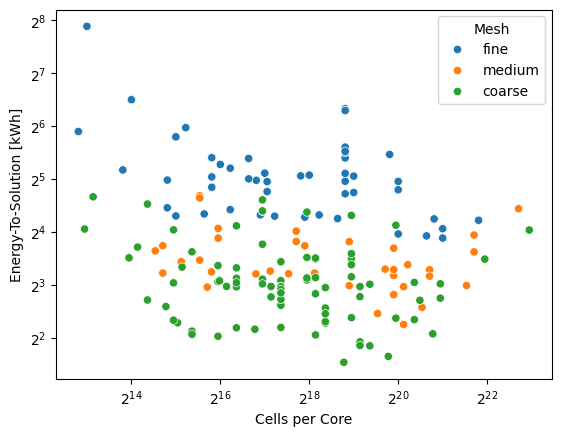

In [20]:
ax = sb.scatterplot(df_hardware, y="Energy-To-Solution [kWh]", x="Cells per Core", hue="Mesh") #, native_scale=True)
ax.set_yscale("log", base=2)
ax.set_xscale("log", base=2)


/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_59204/2859918988.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.boxplot(df_hardware_fine, y="Energy-To-Solution [kWh]", x="year", palette="vlag") #, native_scale=True)


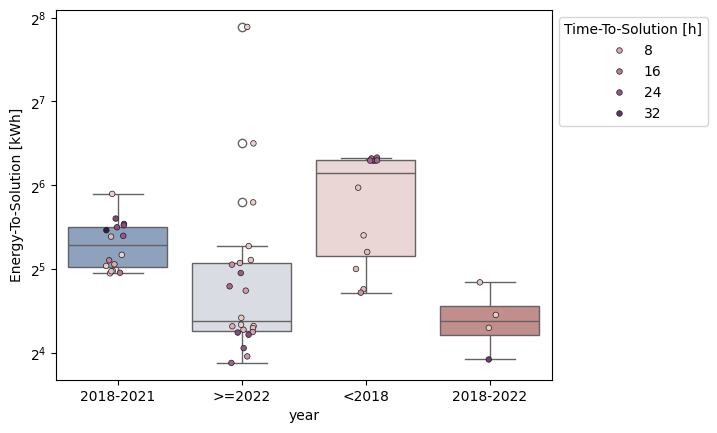

In [21]:

df_hardware["Nodes"] = pd.cut(df_hardware["Number of Nodes"], bins=[0.1,1,2,16,64000], labels=["1","1-2","2-16", ">16"])
df_hardware_fine = df_hardware[df_hardware["Mesh"] == "fine"]
ax = sb.boxplot(df_hardware_fine, y="Energy-To-Solution [kWh]", x="year", palette="vlag") #, native_scale=True)
# Add in points to show each observation
sb.stripplot(df_hardware_fine, x="year", y="Energy-To-Solution [kWh]", size=4, hue="Time-To-Solution [h]", linewidth=0.5)
ax.set_yscale("log", base=2)
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

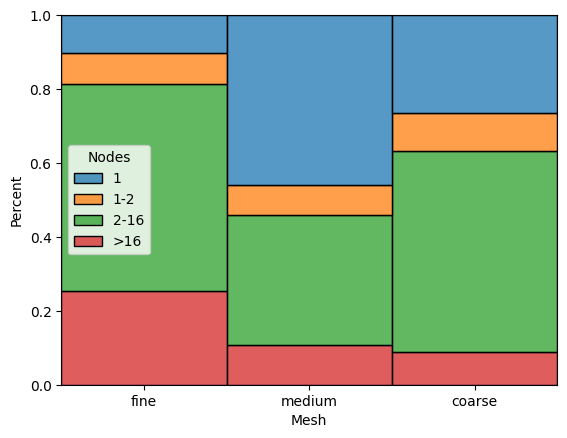

In [114]:
ax = sb.histplot(df_hardware, x="Mesh",
            hue="Nodes",
            #hue="Contributor ID", 
            multiple="fill",
            stat="percent",
           )

# Strong Scaling

In [9]:
from sklearn import datasets, linear_model
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
from scipy.stats import expon


/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_63329/1965200703.py:18: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(tts, X.values.ravel(), y.values.ravel())
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_63329/1965200703.py:18: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(tts, X.values.ravel(), y.values.ravel())
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_63329/1965200703.py:18: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(tts, X.values.ravel(), y.values.ravel())
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_63329/1965200703.py:18: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(tts, X.values.ravel(), y.values.ravel())
/var/folders/9k/fsqnnjlj7n10pwdjq41gzd340000gn/T/ipykernel_63329/1965200703.py:18: OptimizeWarning: Covariance of the parameters

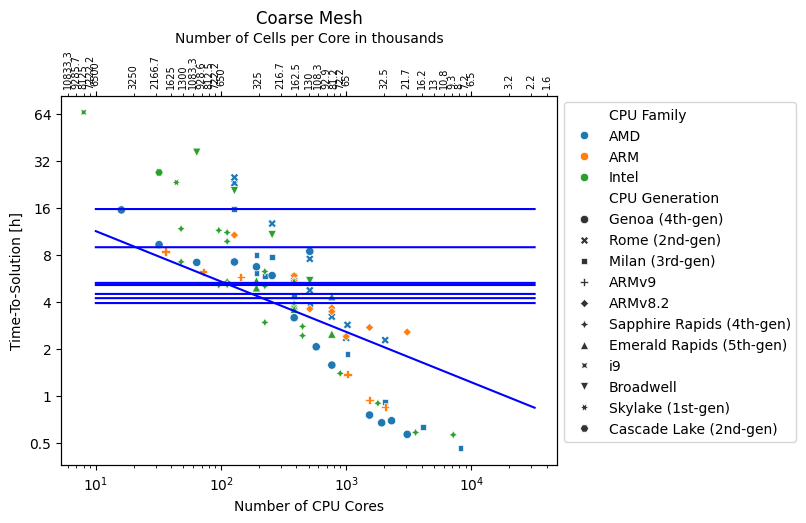

In [39]:
ax = sb.scatterplot(df_hw_coarse.sort_values("CPU Family"),x="Number of CPU Cores", y="Time-To-Solution [h]", hue="CPU Family", style="CPU Generation")

def tts(nc, a, b, c):
    return  a * np.exp(-b * nc) + c
    
gen = set(df_hw_coarse["CPU Generation"])

for g in gen:
    df_filt = df_hw_coarse[df_hw_coarse["CPU Generation"] == g]
    
    X = df_filt[["Number of CPU Cores"]]
    y = df_filt[["Time-To-Solution [h]"]]

#regressor = LinearRegression()
#regressor.fit(X, y_fit)
#y_pred = regressor.predict(X)
    try:
        popt, pcov = curve_fit(tts, X.values.ravel(), y.values.ravel())
        #popt, pcov = curve_fit(tts, X.values, y.values)
        plt.plot(np.array([10,32000]), tts(np.array([10,32000]), *popt), color = 'blue')
    except:
        continue

ax.set(xscale="log", title="Coarse Mesh")
ax.set_yscale("log", base=2)

ax.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
addSecondaryAxisCellsPerCore(ax, size_coarse)
fig = ax.get_figure()

saving figure to figures_hwtrack/strong_scaling_coarse.png


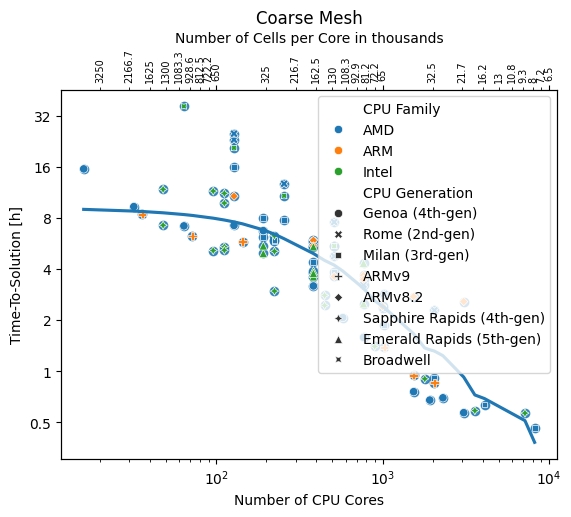

In [8]:
# Use only CPUs with more than one entry per submodel
df_hw_coarse_scaling = df_hw_coarse[df_hw_coarse.groupby("CPU Submodel")["CPU Submodel"].transform(len) > 2]
ax = sb.regplot(df_hw_coarse_scaling.sort_values("CPU Family"), x="Number of CPU Cores", y="Time-To-Solution [h]", 
                #hue="CPU Family",
                #style="CPU Generation",
                    #marker='s', markersize=5
                   # order=0,
                   lowess=True,
                   #robust=True,
                   #logx=True
               )
ax = sb.scatterplot(df_hw_coarse_scaling.sort_values("CPU Family"), x="Number of CPU Cores", y="Time-To-Solution [h]",
                hue="CPU Family", style="CPU Generation",
                    #marker='s', markersize=5
                   )
ax.set(xscale="log", title="Coarse Mesh")
ax.set_yscale("log", base=2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
addSecondaryAxisCellsPerCore(ax, size_coarse)
#sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "strong_scaling_coarse", doSaveFig)

saving figure to figures_hwtrack/strong_scaling_medium.png


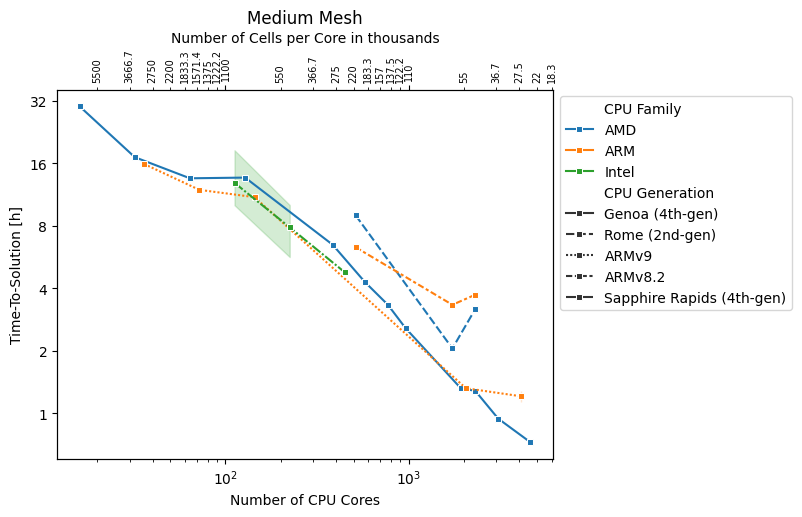

In [122]:
# Use only CPUs with more than one entry per submodel
df_hw_medium_scaling = df_hw_medium[df_hw_medium.groupby("CPU Submodel")["CPU Submodel"].transform(len) > 2]
ax = sb.lineplot(df_hw_medium_scaling.sort_values("CPU Family"), x="Number of CPU Cores", y="Time-To-Solution [h]", hue="CPU Family", style="CPU Generation", marker='s', markersize=5)
ax.set(xscale="log", title="Medium Mesh")
ax.set_yscale("log", base=2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
addSecondaryAxisCellsPerCore(ax, size_medium)
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "strong_scaling_medium", doSaveFig)

saving figure to figures_hwtrack/strong_scaling_fine.png


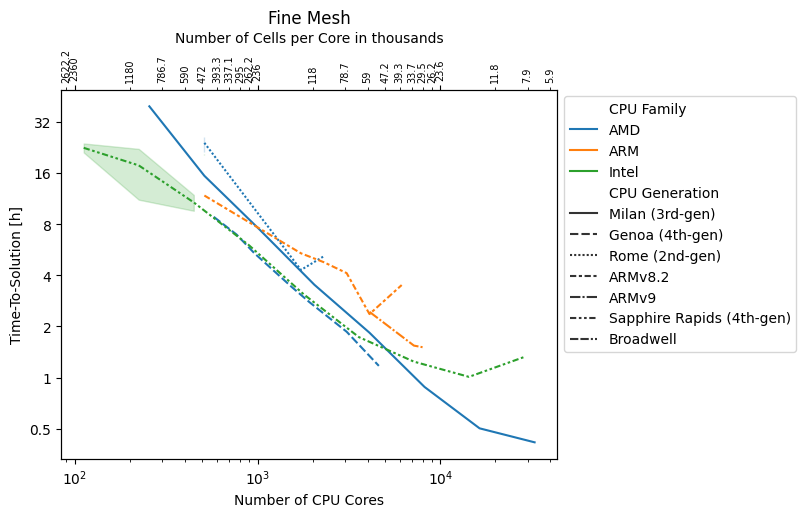

In [123]:
# Use only CPUs with more than one entry per submodel
df_hw_fine_scaling = df_hw_fine[df_hw_fine.groupby("CPU Submodel")["CPU Submodel"].transform(len) > 2]
ax = sb.lineplot(df_hw_fine_scaling.sort_values("CPU Family"), x="Number of CPU Cores", y="Time-To-Solution [h]", hue="CPU Family", style="CPU Generation")
ax.set(xscale="log", title="Fine Mesh")
ax.set_yscale("log", base=2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
addSecondaryAxisCellsPerCore(ax, size_fine)
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "strong_scaling_fine", doSaveFig)

## Parallel Efficiency

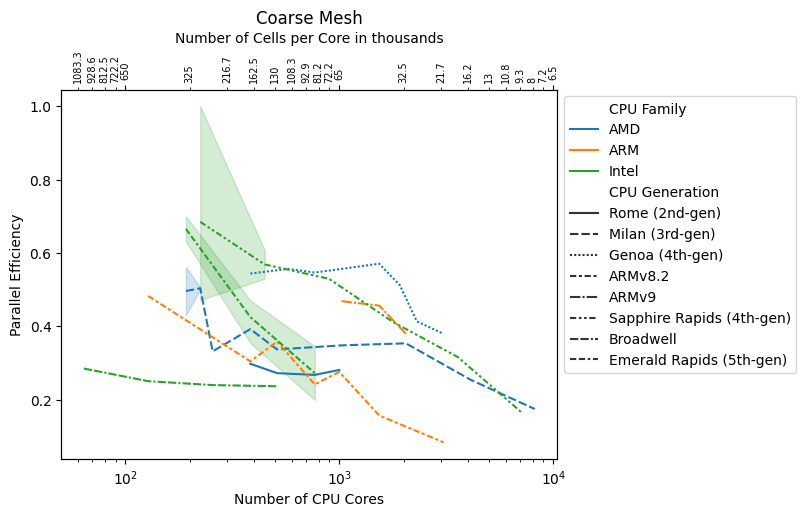

In [227]:
df = df_hw_coarse_scaling
df = df.reset_index(drop=True)
df = df[df["Number of Nodes"] > 1]
df["Total Core Time [s]"] = df["Time-To-Solution [h]"] * df["Number of CPU Cores"]
maxT_val = df["Total Core Time [s]"].min()
maxT_id = df["Total Core Time [s]"].idxmin()
df = df.assign(maxT=maxT_val)
df["Parallel Efficiency"] = df["maxT"] / df["Time-To-Solution [h]"] / df["Number of CPU Cores"]
ax = sb.lineplot(df.sort_values("CPU Model"), x="Number of CPU Cores", y="Parallel Efficiency", hue="CPU Family", style="CPU Generation")
ax.set(xscale="log", title="Coarse Mesh")
addSecondaryAxisCellsPerCore(ax, size_coarse)
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "parallel-efficiency_cores_coarse", doSaveFig)

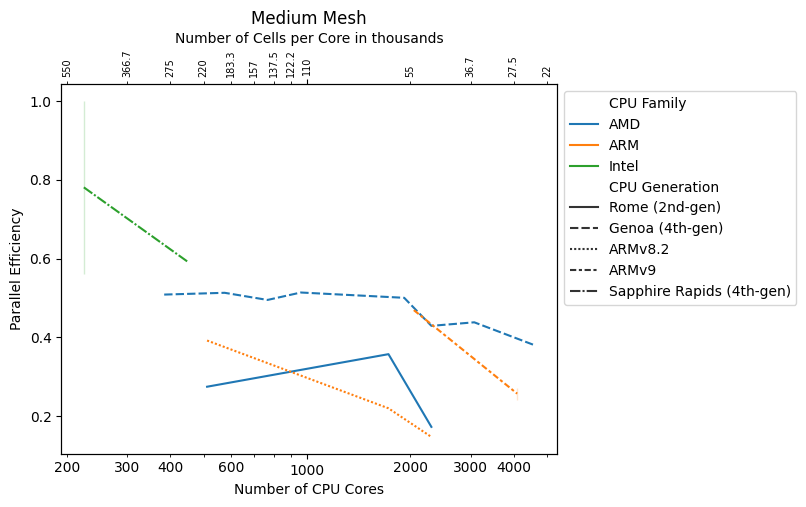

In [228]:
df = df_hw_medium_scaling
df = df.reset_index(drop=True)
df = df[df["Number of Nodes"] > 1]
df["Total Core Time [s]"] = df["Time-To-Solution [h]"] * df["Number of CPU Cores"]
maxT_val = df["Total Core Time [s]"].min()
maxT_id = df["Total Core Time [s]"].idxmin()
df = df.assign(maxT=maxT_val)
df["Parallel Efficiency"] = df["maxT"] / df["Time-To-Solution [h]"] / df["Number of CPU Cores"]
ax = sb.lineplot(df.sort_values("CPU Family"), x="Number of CPU Cores", y="Parallel Efficiency", hue="CPU Family", style="CPU Generation")
ax.set(xscale="log", title="Medium Mesh")
formatter = matplotlib.ticker.LogFormatter(labelOnlyBase=False, minor_thresholds=(3, 1))
ax.xaxis.set_minor_formatter(formatter)
ax.xaxis.set_major_formatter(formatter)
addSecondaryAxisCellsPerCore(ax, size_medium)
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "parallel-efficiency_cores_medium", doSaveFig)

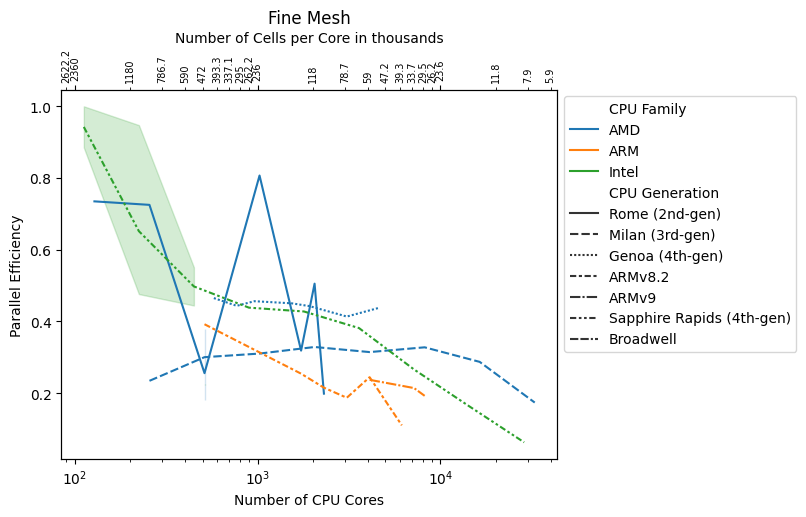

In [229]:
df = df_hw_fine_scaling
df = df.reset_index(drop=True)
df["Total Core Time [s]"] = df["Time-To-Solution [h]"] * df["Number of CPU Cores"]
maxT_val = df["Total Core Time [s]"].min()
maxT_id = df["Total Core Time [s]"].idxmin()
df = df.assign(maxT=maxT_val)
df["Parallel Efficiency"] = df["maxT"] / df["Time-To-Solution [h]"] / df["Number of CPU Cores"]
ax = sb.lineplot(df.sort_values("CPU Model"), x="Number of CPU Cores", y="Parallel Efficiency", hue="CPU Family", style="CPU Generation")
ax.set(xscale="log", title="Fine Mesh")
addSecondaryAxisCellsPerCore(ax, size_fine)
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "parallel-efficiency_cores_fine", doSaveFig)

## Single Node

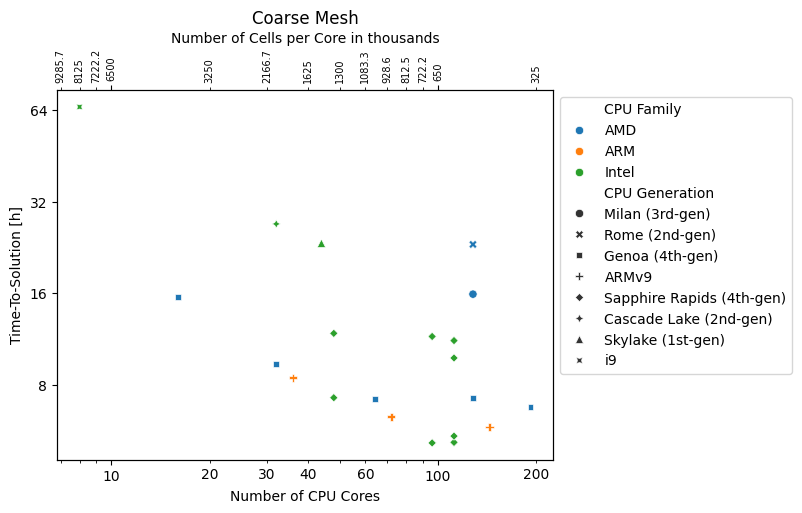

In [230]:
df = df_hw_coarse
df = df[df["Number of Nodes"] == 1]
ax = sb.scatterplot(df.sort_values("CPU Family"),x="Number of CPU Cores", y="Time-To-Solution [h]", hue="CPU Family", style="CPU Generation")
ax.set(xscale="log", title="Coarse Mesh")
ax.set_yscale("log", base=2)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.4g'))
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
formatter = matplotlib.ticker.LogFormatter(labelOnlyBase=False, minor_thresholds=(2, 1))
ax.xaxis.set_minor_formatter(formatter)
addSecondaryAxisCellsPerCore(ax, size_coarse)
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

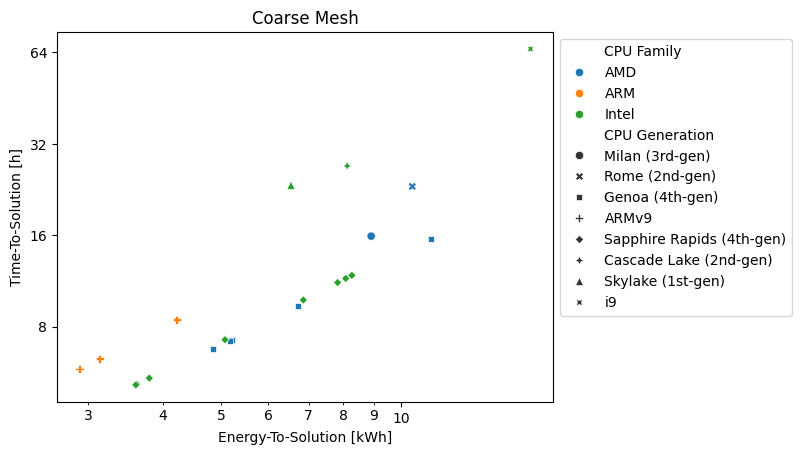

In [231]:
df = df_hw_coarse
df = df[df["Number of Nodes"] == 1]
ax = sb.scatterplot(df.sort_values("CPU Family"),x="Energy-To-Solution [kWh]", y="Time-To-Solution [h]", hue="CPU Family", style="CPU Generation")
ax.set(xscale="log", title="Coarse Mesh")
ax.set_yscale("log", base=2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.4g'))
formatter = matplotlib.ticker.LogFormatter(labelOnlyBase=False, minor_thresholds=(2, 1))
ax.xaxis.set_minor_formatter(formatter)
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

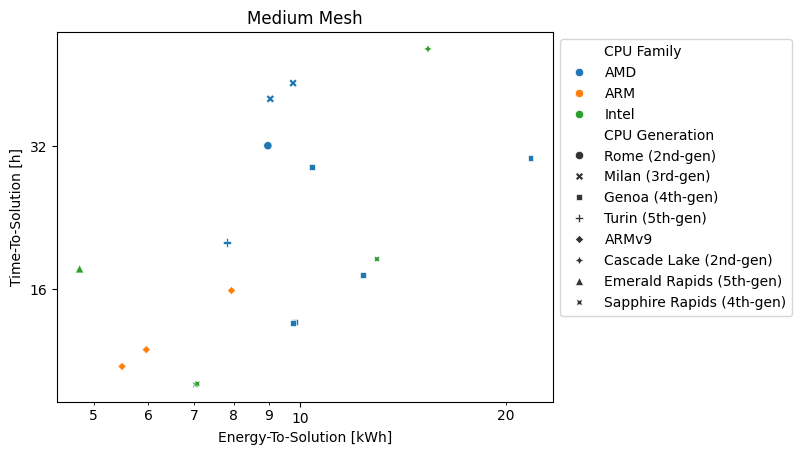

In [232]:
df = df_hw_medium
df = df[df["Number of Nodes"] == 1]
ax = sb.scatterplot(df.sort_values("CPU Family"),x="Energy-To-Solution [kWh]", y="Time-To-Solution [h]", hue="CPU Family", style="CPU Generation")
ax.set(xscale="log", title="Medium Mesh")
ax.set_yscale("log", base=2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.4g'))
formatter = matplotlib.ticker.LogFormatter(labelOnlyBase=False, minor_thresholds=(3, 1))
ax.xaxis.set_minor_formatter(formatter)
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

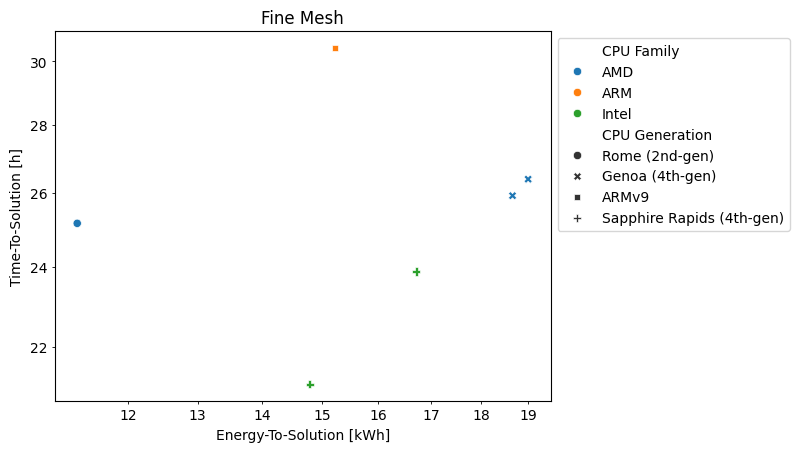

In [233]:
df = df_hw_fine
df = df[df["Number of Nodes"] == 1]
ax = sb.scatterplot(df.sort_values("CPU Family"),x="Energy-To-Solution [kWh]", y="Time-To-Solution [h]", hue="CPU Family", style="CPU Generation")
ax.minorticks_on()
ax.set(xscale="log", title="Fine Mesh")
ax.set_yscale("log", base=2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.4g'))
formatter = matplotlib.ticker.LogFormatter(labelOnlyBase=False, minor_thresholds=(2, 1))
ax.xaxis.set_minor_formatter(formatter)
ax.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(numticks=999, subs="auto"))
ax.yaxis.set_minor_formatter(formatter)
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

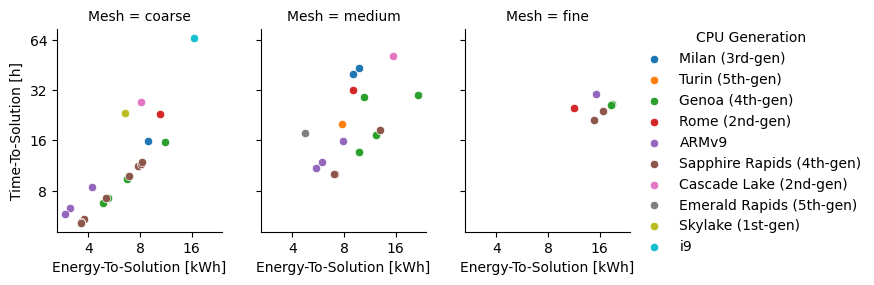

In [234]:
df = df_hardware
df = df[df["Number of Nodes"] == 1]
g = sb.FacetGrid(df.sort_values("CPU Family"), col="Mesh", hue="CPU Generation", aspect=0.75, sharey=True, subplot_kws={"yscale":"log", "xscale":"log" }, col_order=["coarse","medium","fine"], legend_out=True)
g.map_dataframe(sb.scatterplot, y="Time-To-Solution [h]", x="Energy-To-Solution [kWh]")
g.add_legend()
for ax in g.axes.flat:
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.4g'))
    ax.set_yscale("log", base=2)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.4g'))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "TTS_ETS_facetGrid-singleNode", doSaveFig)

# Last-Level Cache

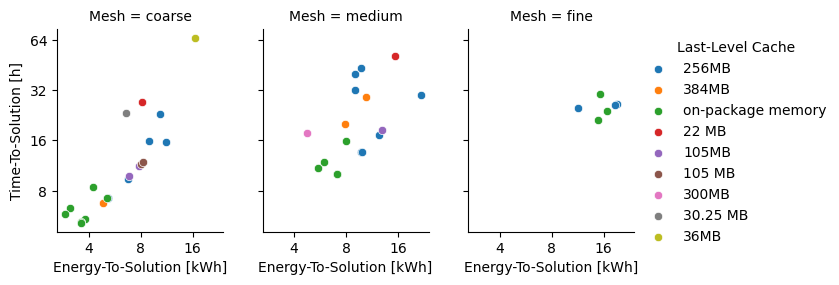

In [235]:
df = df_hardware
df = df[df["Number of Nodes"] == 1]
g = sb.FacetGrid(df.sort_values("CPU Family"), col="Mesh", hue="Last-Level Cache", aspect=0.75, sharey=True, subplot_kws={"yscale":"log", "xscale":"log" }, col_order=["coarse","medium","fine"], legend_out=True)
g.map_dataframe(sb.scatterplot, y="Time-To-Solution [h]", x="Energy-To-Solution [kWh]")
g.add_legend()
for ax in g.axes.flat:
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.4g'))
    ax.set_yscale("log", base=2)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.4g'))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "TTS_ETS_facetGrid-singleNode-Last-Level Cache", doSaveFig)

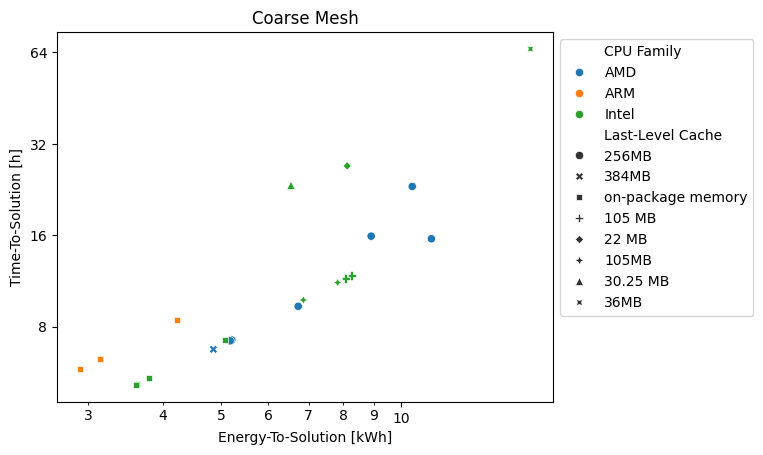

In [236]:
df = df_hw_coarse
df = df[df["Number of Nodes"] == 1]
ax = sb.scatterplot(df.sort_values("CPU Family"),x="Energy-To-Solution [kWh]", y="Time-To-Solution [h]", hue="CPU Family", style="Last-Level Cache")
ax.set(xscale="log", title="Coarse Mesh")
ax.set_yscale("log", base=2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.4g'))
formatter = matplotlib.ticker.LogFormatter(labelOnlyBase=False, minor_thresholds=(2, 1))
ax.xaxis.set_minor_formatter(formatter)
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "Last-Level Cache-singleNode-coarse", doSaveFig)

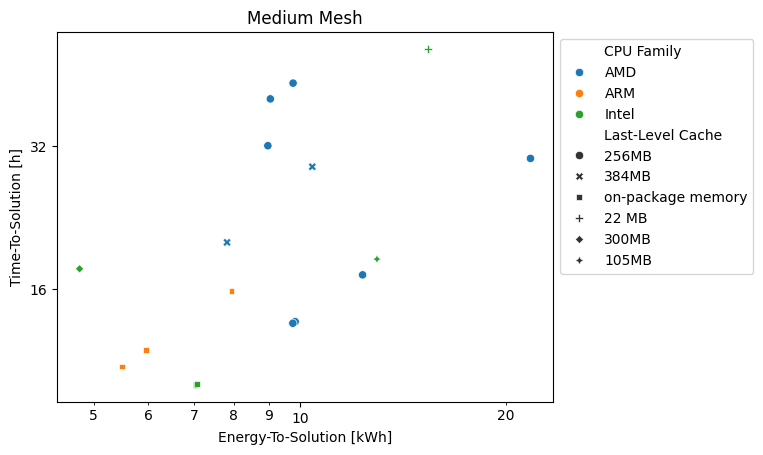

In [237]:
df = df_hw_medium
df = df[df["Number of Nodes"] == 1]
ax = sb.scatterplot(df.sort_values("CPU Family"),x="Energy-To-Solution [kWh]", y="Time-To-Solution [h]", hue="CPU Family", style="Last-Level Cache")
ax.set(xscale="log", title="Medium Mesh")
ax.set_yscale("log", base=2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.4g'))
formatter = matplotlib.ticker.LogFormatter(labelOnlyBase=False, minor_thresholds=(3, 1))
ax.xaxis.set_minor_formatter(formatter)
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "Last-Level Cache-singleNode-medium", doSaveFig)


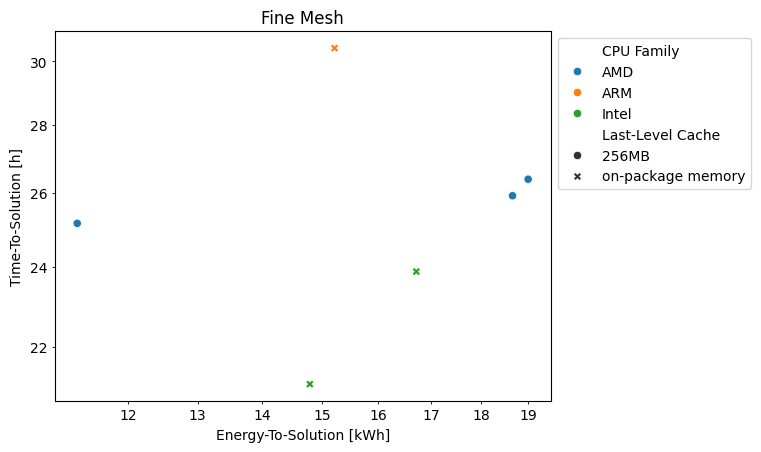

In [238]:
df = df_hw_fine
df = df[df["Number of Nodes"] == 1]
ax = sb.scatterplot(df.sort_values("CPU Family"),x="Energy-To-Solution [kWh]", y="Time-To-Solution [h]", hue="CPU Family", style="Last-Level Cache")
ax.minorticks_on()
ax.set(xscale="log", title="Fine Mesh")
ax.set_yscale("log", base=2)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.4g'))
formatter = matplotlib.ticker.LogFormatter(labelOnlyBase=False, minor_thresholds=(2, 1))
ax.xaxis.set_minor_formatter(formatter)
ax.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(numticks=999, subs="auto"))
ax.yaxis.set_minor_formatter(formatter)
sb.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
fig = ax.get_figure()
op.save_fig(fig, fig_folder, "Last-Level Cache-singleNode-fine", doSaveFig)